In [1]:
try:
    import h2o
except:
    %pip install -q -U h2o
    import h2o
    
from h2o import H2OFrame
from h2o.automl import H2OAutoML

print("h2o version:", h2o.__version__)

h2o version: 3.46.0.11


In [2]:
## -- System dependencies --
import sys, os, gc
import torch

## -- Device-Agnostic (GPU/CPU) --
def get_system_info():
    if torch.cuda.is_available():
        return f"GPU: {torch.cuda.get_device_name(0)}"
    else:
        return f"CPU: {os.cpu_count()}"

get_system_info()

'CPU: 4'

In [3]:
## -- Data Manipulation --
import numpy as np, pandas as pd, random

## -- Visualization --
from IPython.display import display, Image
import matplotlib.pyplot as plt
import seaborn as sns
# import shap

## -- Functional Tools --
from time import time, sleep
from tqdm.notebook import tqdm
import itertools

## -- Machine Learning --
from sklearn.base import clone
from sklearn.frozen import FrozenEstimator
from sklearn.pipeline import make_pipeline
from sklearn.compose import make_column_transformer
from sklearn.calibration import CalibratedClassifierCV
from sklearn.utils.class_weight import compute_class_weight
from sklearn.feature_selection import mutual_info_regression
from sklearn.metrics import balanced_accuracy_score, ConfusionMatrixDisplay
from sklearn.model_selection import KFold, StratifiedKFold, train_test_split
from sklearn.preprocessing import TargetEncoder, OneHotEncoder, LabelEncoder, label_binarize

import warnings
warnings.simplefilter('ignore')
warnings.filterwarnings('ignore')

In [4]:
# sklearn.set_config(transform_output="pandas")
# pd.options.mode.copy_on_write = True

pd.set_option('display.max_columns', 1000)
sns.set_style("whitegrid")
# plt.style.use('ggplot')

# # plt.rcParams['axes.prop_cycle'] = cycler(color=['red', 'green', 'blue'])
# plt.rcParams.update({
#     "figure.facecolor": '#0f0f1a', # Outer panel (figure)
#     "axes.facecolor":   '#1a1a2e', # Inner panel (image)
#     "axes.edgecolor":   '#444466',
#     "axes.labelcolor":  '#e0e0ff',
#     "text.color":       'lightblue',
#     "xtick.color":      '#e0e0ff',
#     "ytick.color":      '#e0e0ff',
#     "grid.color":       '#2a2a4a',
#     "grid.alpha":       0.5,
#     "font.family":      'monospace',
# })

cmap = sns.diverging_palette(0, 230, 90, 60, as_cmap=True)
PALETTE = ['c', 'r', 'darkorange', '#3A86FF', 'y']
sns.set_palette(PALETTE)

## -- Set Global Configuration --
CFG = {
    'FOLDS': 5,
    'SEED': 42,
    'GREEN': '\033[32m',
    'YELLOW': '\033[33m',
    'RED': '\033[31m',
    'RESET': '\033[0m'
}

print(f"CLASSIC {CFG['GREEN']} GREEN {CFG['RESET']}")
print(f"{CFG['YELLOW']}YELLOW {CFG['RESET']} {CFG['RED']} RED {CFG['RESET']}")

CLASSIC  GREEN 
YELLOW   RED 


In [5]:
## -- ⚠️ IMPORTANT: SELECT PLATFORM ⚠️ --
PLATFORM = 'kaggle' # -> 'colab' 'kaggle'

if PLATFORM == 'kaggle':
    PATH = '/kaggle/input/competitions/playground-series-s6e7/'
    submit = pd.read_csv(PATH+'sample_submission.csv')
    train = pd.read_csv(PATH+'train.csv')
    test = pd.read_csv(PATH+'test.csv')

    ORIG_PATH = '/kaggle/input/datasets/ziya07/college-student-health-behavior-dataset/'
    orig = pd.read_csv(ORIG_PATH+'student_health_dataset_50k.csv')
elif PLATFORM == 'colab':
    from google.colab import drive
    drive.mount('/content/drive')

    PATH = '/content/drive/MyDrive/-- shared_notebooks --/Ps6e7 | Student Health/_student_health_data/'
    submit = pd.read_csv(PATH+'sample_submission.csv')
    train = pd.read_csv(PATH+'train.csv')
    test = pd.read_csv(PATH+'test.csv')
    orig = pd.read_csv(PATH+'student_health_dataset_50k.csv')

## =================================================================================

ID = 'id'
TARGET  = 'health_condition'
OBJECTS = train.select_dtypes(include=['object', 'category']).columns.tolist()

CATS = [c for c in OBJECTS if c not in [TARGET, ID]]
NUMS = [c for c in train.columns if c not in CATS+[TARGET, ID]]
BASE = NUMS + CATS

# {c: i for i, c in enumerate(train[TARGET].unique())}
mapping   = {'fit': 0, 'at-risk': 1, 'unhealthy': 2}
r_mapping = {v: k for k, v in mapping.items()}

# for df in [train, orig]:
#     df[TARGET] = df[TARGET].map(mapping)

for (name, df) in {'Train': train, 'Test': test, 'Orig': orig}.items():
    print(f"{name} shape: {df.shape}")

print(f"\nTotal Numerical: {len(NUMS)}")
print(f"Total Categorical: {len(CATS)}")
print(f"Total base features: {len(BASE)}")

Train shape: (690088, 15)
Test shape: (295753, 14)
Orig shape: (50000, 16)

Total Numerical: 7
Total Categorical: 6
Total base features: 13


In [6]:
display(train.head())
train.info()

,id,health_condition,sleep_duration,heart_rate,bmi,calorie_expenditure,step_count,exercise_duration,water_intake,diet_type,stress_level,sleep_quality,physical_activity_level,smoking_alcohol,gender
0,0,unhealthy,5.22,70.6,25.66,2174.0,1326.0,19.8,1.86,veg,high,average,sedentary,yes,female
1,1,at-risk,5.53,71.3,25.84,1966.0,9891.0,49.9,1.26,non-veg,low,average,moderate,yes,other
2,2,unhealthy,5.29,75.4,24.54,2688.0,14216.0,38.1,1.60,veg,high,poor,active,yes,male
3,3,unhealthy,4.70,77.2,23.13,2630.0,7174.0,59.9,2.02,veg,high,average,active,occasional,female
4,4,at-risk,7.23,73.4,28.44,2560.0,6584.0,46.0,2.25,veg,NaN,average,sedentary,NaN,male


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 690088 entries, 0 to 690087
Data columns (total 15 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   id                       690088 non-null  int64  
 1   health_condition         690088 non-null  object 
 2   sleep_duration           614089 non-null  float64
 3   heart_rate               682255 non-null  float64
 4   bmi                      676190 non-null  float64
 5   calorie_expenditure      637235 non-null  float64
 6   step_count               676172 non-null  float64
 7   exercise_duration        683187 non-null  float64
 8   water_intake             646611 non-null  float64
 9   diet_type                683187 non-null  object 
 10  stress_level             607277 non-null  object 
 11  sleep_quality            631757 non-null  object 
 12  physical_activity_level  653467 non-null  object 
 13  smoking_alcohol          661506 non-null  object 
 14  gend

In [7]:
train[NUMS].describe()

,sleep_duration,heart_rate,bmi,calorie_expenditure,step_count,exercise_duration,water_intake
count,614089.000000,682255.000000,676190.000000,637235.000000,676172.000000,683187.000000,646611.000000
mean,6.992597,75.096504,22.984925,2226.084931,8615.953050,38.751456,2.188542
std,1.215407,8.175106,2.481787,347.532098,3929.399831,14.742189,0.518489
min,3.000000,50.000000,16.000000,1200.000000,1002.000000,0.000000,0.500000
25%,6.160000,69.400000,21.320000,2053.000000,5389.000000,29.200000,1.840000
50%,6.990000,75.100000,22.990000,2241.000000,8856.000000,39.400000,2.170000
75%,7.810000,80.700000,24.660000,2456.000000,12114.000000,49.400000,2.500000
max,10.000000,107.700000,34.820000,3580.000000,14999.000000,99.800000,4.720000


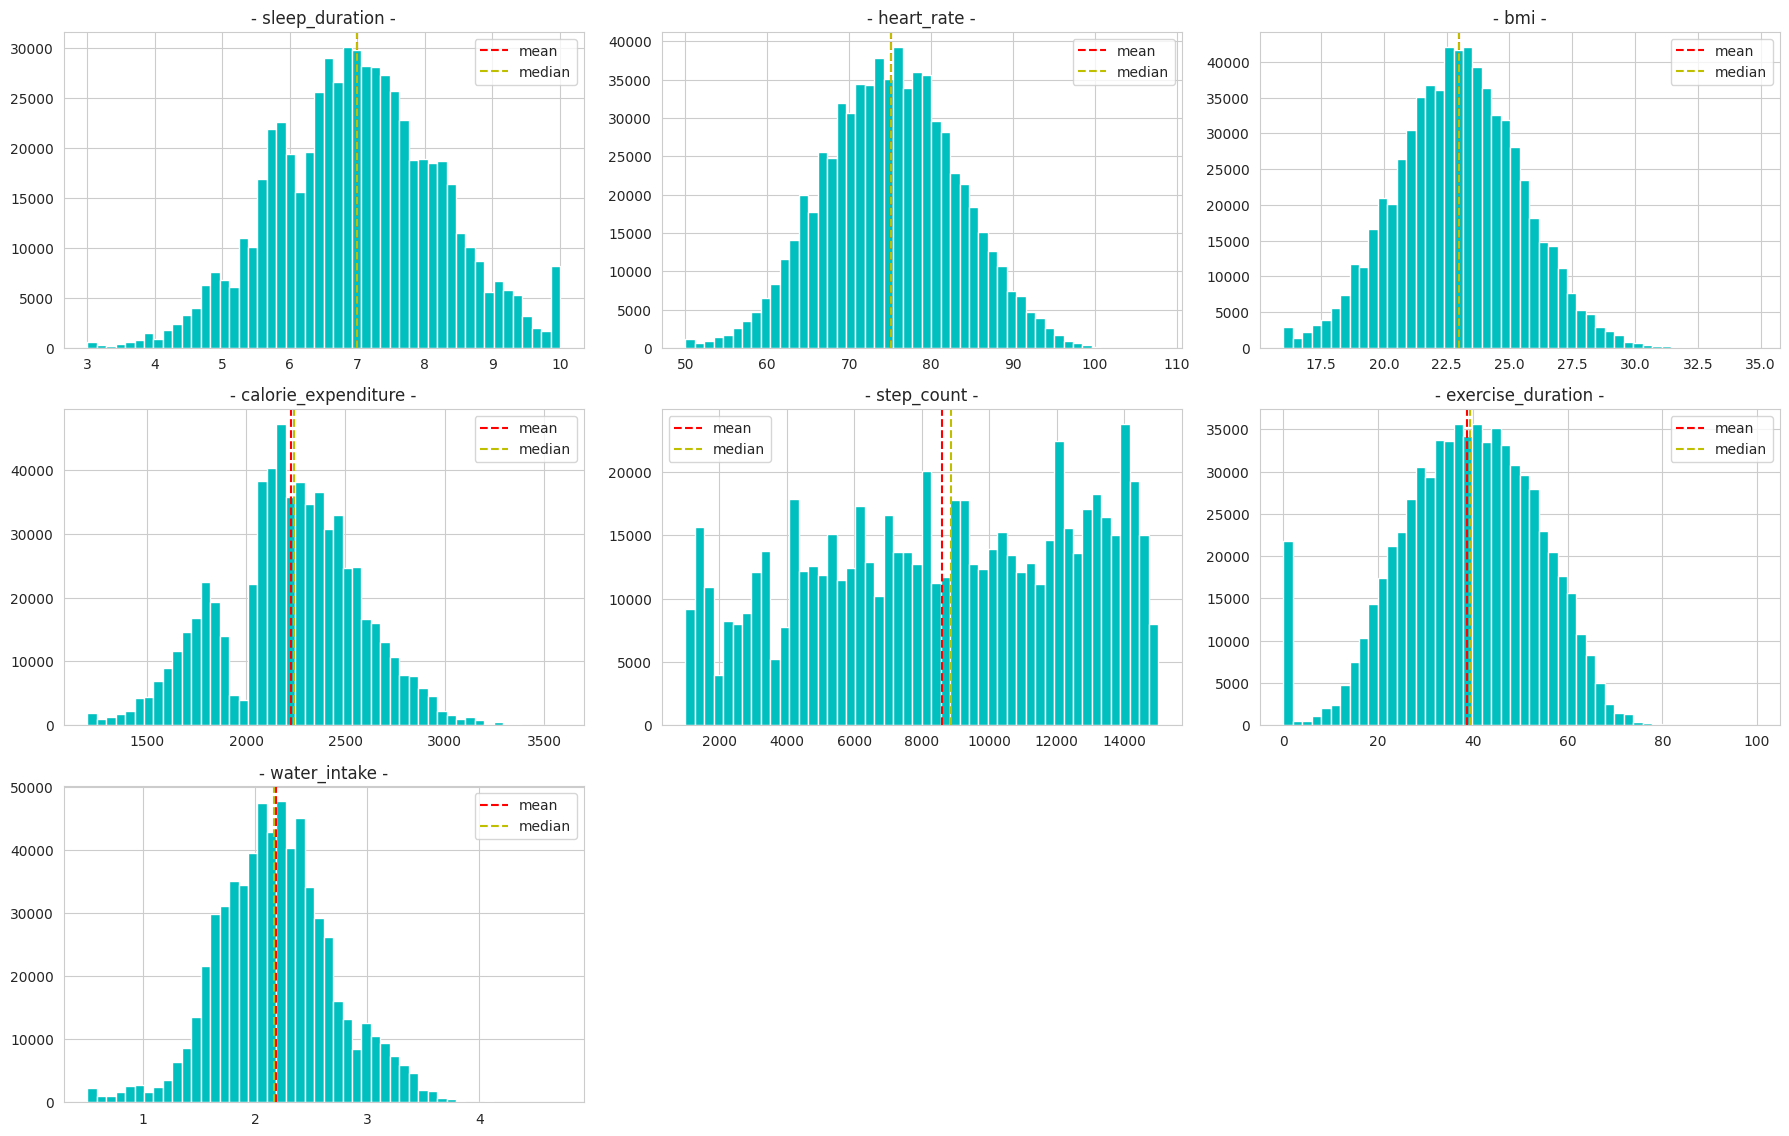

In [8]:
plt.figure(figsize=(18, 15))

for i, col in enumerate(NUMS):
    plt.subplot(4, 3, i+1)
    ax = plt.hist(train[col], bins=50)
    plt.axvline(x=train[col].mean(), color='r', linestyle='--', label='mean')
    plt.axvline(x=train[col].median(), color='y', linestyle='--', label='median')
    plt.title(f'- {col} -')
    plt.legend()

plt.tight_layout()
plt.show()

In [9]:
## -- Unique value counts for each dataset --
TRAIN_UNIQUE = {}
ORIGINAL_UNIQUE = {}
TEST_UNIQUE = {}

for col in BASE:
    TRAIN_UNIQUE[col] = train[col].nunique()
    ORIGINAL_UNIQUE[col] = orig[col].nunique()
    TEST_UNIQUE[col] = test[col].nunique()

unique_counts_df = pd.concat(
        [pd.DataFrame(TRAIN_UNIQUE, index=['Train']),
         pd.DataFrame(ORIGINAL_UNIQUE, index=['Original']),
         pd.DataFrame(TEST_UNIQUE, index=['Test'])],
    )

unique_counts_df.style.background_gradient()

,sleep_duration,heart_rate,bmi,calorie_expenditure,step_count,exercise_duration,water_intake,diet_type,stress_level,sleep_quality,physical_activity_level,smoking_alcohol,gender
Train,701,537,1596,2101,12807,856,400,3,3,3,3,3,3
Original,700,585,1627,2179,13601,1041,412,3,3,3,3,3,3
Test,692,526,1548,2068,12196,817,392,3,3,3,3,3,3


In [10]:
n_unique = train[BASE].nunique().sort_values()
n_unique

diet_type                      3
physical_activity_level        3
sleep_quality                  3
gender                         3
smoking_alcohol                3
stress_level                   3
water_intake                 400
heart_rate                   537
sleep_duration               701
exercise_duration            856
bmi                         1596
calorie_expenditure         2101
step_count                 12807
dtype: int64

In [11]:
def get_class_weights(y):
    """
    y: Current y labels -> numpy array or series
    """
    cls_ = np.unique(y)
    wts_ = compute_class_weight("balanced", classes=cls_, y=y)
    return dict(zip(cls_, wts_))

def get_sample_weights(y, y_true, opt='auto'):
    """
    y: Current y labels -> numpy array or series
    y_true: True labels -> numpy array or series
    opt: 'auto' generate weight or pass a custom dict -> label: weight
    """
    if opt != 'auto':
        return np.array([opt[label] for label in y])
    else:
        cls_ = np.unique(y_true)
        wts_ = compute_class_weight('balanced', classes=cls_, y=y_true)
        cls_wts = dict(zip(cls_, wts_))
        return np.array([cls_wts[label] for label in y])

def balanced_acc(y_true, y_proba):
    pred_labels = np.argmax(y_proba, axis=1)
    return balanced_accuracy_score(y_true, pred_labels)

def multi_class_brier(y_true, y_proba, classes):
    y_onehot = label_binarize(y_true, classes=classes)
    return float(np.mean(np.sum((y_onehot - y_proba) ** 2, axis=1)))

def t_enc_multi(X_tr, X_va, X_ts, y_tr, cols, drop=False):
    X_tr_1 = X_tr.copy()
    X_va_1 = X_va.copy()
    X_ts_1 = X_ts.copy()

    te_enc = TargetEncoder(target_type='multiclass', random_state=CFG['SEED']).set_output(transform='pandas')

    X_tr_te = te_enc.fit_transform(X_tr_1[cols], y_tr)
    X_va_te = te_enc.transform(X_va_1[cols])
    X_ts_te = te_enc.transform(X_ts_1[cols])

    te_names = [f"TE_{c}" for c in X_tr_te.columns]
    X_tr_1[te_names] = X_tr_te
    X_va_1[te_names] = X_va_te
    X_ts_1[te_names] = X_ts_te

    if drop:
        X_tr_1 = X_tr_1.drop(columns=cols)
        X_va_1 = X_va_1.drop(columns=cols)
        X_ts_1 = X_ts_1.drop(columns=cols)

    return X_tr_1, X_va_1, X_ts_1

print('- Helper functions ready -')

- Helper functions ready -


## FEATURE ENGINEERING

In [12]:
## -- Digit extractions & binning --
ROUNDS = []
DIGITS = []
E_BINS = []
Q_BINS = []
DROP_COLS = []

round_thresh = 3
digit_thresh = 2

round_thresh, digit_thresh

(3, 2)

In [13]:
# for col in ['redshift']:
#     # print(f"\nRounding... ", end='')
#     # for r in range(-3, 6):
#     #     r_n = f"{col}_round_{r}"
#     #     print(r_n+', ', end='')
#     #     train[r_n] = train[col].round(r).astype('int32')
#     #     test[r_n]  = test[col].round(r).astype('int32')
#     #     orig[r_n]  = orig[col].round(r).astype('int32')
#     #     ## -- Drop irrelevant features --
#     #     if train[r_n].nunique() < round_thresh or train[r_n].nunique() == train[col].nunique():
#     #         DROP_COLS.append(r_n)
#     #     else:
#     #         ROUNDS.append(r_n)

#     # print(f"\nDigitizing... ", end='')
#     # for d in range(1):
#     #     d_n = f'{col}_{d}_digit_'
#     #     print(d_n+', ', end='')
#     #     train[d_n] = ((train[col] * 10**d) % 10).fillna(-1).astype('int8')
#     #     test[d_n]  = ((test[col]  * 10**d) % 10).fillna(-1).astype('int8')
#     #     orig[d_n]  = ((orig[col]  * 10**d) % 10).fillna(-1).astype('int8')
#     #     ## -- Drop constant features --
#     #     if train[d_n].nunique() < digit_thresh:
#     #         DROP_COLS.append(d_n)
#     #     else:
#     #         DIGITS.append(d_n)

#     # print(f"\nEqual binning... ", end='')
#     # for b in [32, 64, 128]: # 100, 500, 1000
#     #     b_n = f'{col}_bin_{b}'
#     #     print(b_n+', ', end='')
#     #     train[b_n], edges = pd.cut(train[col], bins=b, retbins=True, include_lowest=True, labels=False)
#     #     test[b_n] = pd.cut(test[col], bins=edges, include_lowest=True, labels=False)
#     #     orig[b_n] = pd.cut(orig[col], bins=edges, include_lowest=True, labels=False)
#     #     E_BINS.append(b_n)

#     print(f"\nQuantile binning... ", end='')
#     for q in [4]:
#         q_n = f'{col}_Qbin_{q}'
#         print(q_n+', ', end='')
#         train[q_n], edges = pd.qcut(train[col], q=q, retbins=True, duplicates='drop', labels=False)
#         test[q_n] = pd.cut(test[col], bins=edges, include_lowest=True, labels=False)
#         orig[q_n] = pd.cut(orig[col], bins=edges, include_lowest=True, labels=False)
#         Q_BINS.append(q_n)

# print()
# print('='*50)
# print(f'✅ ROUNDS: {len(ROUNDS)}')
# print(f"✅ DIGITS: {len(DIGITS)}")
# print(f"✅ E_BINS: {len(E_BINS)}")
# print(f"✅ Q_BINS: {len(Q_BINS)}")

In [14]:
# for col in ["delta", "alpha", "redshift"]:
#     print(f"\nRounding... ", end='')
#     for r in range(-3, 5):
#         r_n = f"{col}_round_{r}"
#         print(r_n+', ', end='')
#         train[r_n] = train[col].round(r).astype('int32')
#         test[r_n]  = test[col].round(r).astype('int32')
#         orig[r_n]  = orig[col].round(r).astype('int32')
#         ## -- Drop irrelevant features --
#         if train[r_n].nunique() < round_thresh or train[r_n].nunique() == train[col].nunique():
#             DROP_COLS.append(r_n)
#         else:
#             ROUNDS.append(r_n)
    
#     # print(f"\nExtracting digits... ", end='')
#     # for d in range(-3, 6):
#     #     d_n = f'{col}_digit_{d}'
#     #     print(d_n+', ', end='')
#     #     train[d_n] = ((train[col] * 10**d) % 10).fillna(-1).astype('int8')
#     #     test[d_n]  = ((test[col]  * 10**d) % 10).fillna(-1).astype('int8')
#     #     orig[d_n]  = ((orig[col]  * 10**d) % 10).fillna(-1).astype('int8')

#     #     ## -- Drop constant features --
#     #     if train[d_n].nunique() < digit_thresh:
#     #         DROP_COLS.append(d_n)
#     #     else:
#     #         DIGITS.append(d_n)

#     # print(f"\nEqual binning... ", end='')
#     # for b in [100]: # 50, 100, 400
#     #     b_n = f'{col}_bin_{b}'
#     #     print(b_n+', ', end='')
#     #     # Fit on train data and transform both train and test
#     #     train[b_n], edges = pd.cut(train[col], bins=b, retbins=True, include_lowest=True, labels=False)
#     #     test[b_n] = pd.cut(test[col], bins=edges, include_lowest=True, labels=False)
#     #     orig[b_n] = pd.cut(orig[col], bins=edges, include_lowest=True, labels=False)
#     #     E_BINS.append(b_n)
        
#     # print(f"\nQuantile binning... ", end='')
#     # for q in [100, 500]: 
#     #     q_n = f'{col}_qbin_{q}'
#     #     print(q_n+', ', end='')
#     #     train[q_n], edges = pd.qcut(train[col], q=q, retbins=True, duplicates='drop', labels=False)
#     #     test[q_n] = pd.cut(test[col], bins=edges, include_lowest=True, labels=False)
#     #     orig[q_n] = pd.cut(orig[col], bins=edges, include_lowest=True, labels=False)
#     #     Q_BINS.append(q_n)

# print()
# print('='*50)
# print(f'✅ ROUNDS: {len(ROUNDS)}')
# print(f"✅ DIGITS: {len(DIGITS)}")
# print(f"✅ E_BINS: {len(E_BINS)}")
# print(f"✅ Q_BINS: {len(Q_BINS)}")

In [15]:
train = train.drop(columns=DROP_COLS)
test  = test.drop(columns=DROP_COLS)
orig  = orig.drop(columns=DROP_COLS)

print(f"Features dropped: {DROP_COLS}")

Features dropped: []


In [16]:
train[ROUNDS+DIGITS+E_BINS+Q_BINS].nunique()

Series([], dtype: float64)

In [17]:
# plt.figure(figsize=(18, 5))
# ax = (train.groupby(by=Q_BINS[0])[TARGET].mean() / 3).plot(linestyle='-.', label=Q_BINS[0])
# (train.groupby(by=Q_BINS[2])[TARGET].mean() / 3).plot(linestyle='-.', ax=ax, label=Q_BINS[2])

# plt.legend()
# plt.show()

In [18]:
# def add_frequency_condition(df1, cols, thresh=5): 
#     df = df1.copy()
#     for c in cols:
#         v_counts = df[c].value_counts()
#         to_replace = v_counts[v_counts <= thresh].index
#         df[c] = np.where(df[c].isin(to_replace), -1, df[c])

#     return df

# train = add_frequency_condition(train, DIGITS+ROUNDS, thresh=5)
# test  = add_frequency_condition(test,  DIGITS+ROUNDS, thresh=5)
# orig  = add_frequency_condition(orig,  DIGITS+ROUNDS, thresh=5)

# print(f"Frequency threshold imputed!")

In [19]:
# ## -- Arithmetic interaction --
# for df in tqdm([train, test, orig]):
#     df['_sub_u_g'] = df['u'] - df['g']
#     df['_sub_g_r'] = df['g'] - df['r']
#     df['_sub_g_i'] = df['g'] - df['i']
#     df['_sub_r_z'] = df['r'] - df['z']
#     df['_sub_i_z'] = df['i'] - df['z']
#     df['_sub_r_i'] = df['r'] - df['i']

#     df["_stellar_locus_dist"] = np.sqrt((df['_sub_g_r'] - 0.52)**2 + (df['_sub_r_i'] - 0.25)**2)

#     for band in ['g', 'i']:
#         b_col = f"_div_{band}_redshift"
#         df[b_col] = df[band] / (df['redshift'] + 1e-6)

# color_bands = [c for c in train.columns if c.startswith('_sub_') or c.startswith('_div_')]
# color_bands.append("_stellar_locus_dist")

# train[color_bands].describe()

In [20]:
# ## -- Cyclic encoding --
# for df in [train, test, orig]:
#     for col in ['alpha']:
#         for p in [180, 360]:
#             df[f"{col}_{p}_sin_"] = np.sin(2 * np.pi * df[col] / p)
#             df[f"{col}_{p}_cos_"] = np.cos(2 * np.pi * df[col] / p)

# for df in [train, test, orig]:
#     for col in ['delta']:
#         for p in [180]:
#             df[f"{col}_{p}_sin_"] = np.sin(2 * np.pi * df[col] / p)
#             df[f"{col}_{p}_cos_"] = np.cos(2 * np.pi * df[col] / p)

# cyclic_cols = [c for c in train.columns if c.endswith('_sin_') or c.endswith('_cos_')]

# train[cyclic_cols].head()

In [21]:
# ## -- Frequency encoding --
# freq_cols = []

# print(f"\nCreating frequencies... ", end='')
# for col in CATS:
#     freq = pd.concat([train[col], orig[col], test[col]]).value_counts(normalize=True)
#     n = f'{col}_freq'
#     print(n+', ', end='')
#     for df in [train, test, orig]:
#         df[n] = df[col].map(freq).fillna(0).astype('float32')
#     freq_cols.append(n)

# print(f"\n✓ Total frequency features: {len(freq_cols)}")

In [22]:
# INTER = []

# for c1, c2 in tqdm(list(itertools.combinations(CATS, 2)), desc='Pairwise'):
#     n_col = f"_Bi_{c1}-|-{c2}"
#     train[n_col] = train[c1].astype(str) + '_' + train[c2].astype(str)
#     test[n_col]  = test[c1].astype(str) + '_' + test[c2].astype(str)
#     orig[n_col]  = orig[c1].astype(str) + '_' + orig[c2].astype(str)
#     INTER.append(n_col)

# # for c1, c2, c3 in tqdm(list(itertools.combinations(TOP_COLS, 3)), desc='Triplewise'):
# #     n_col = f"_Tri_{c1}-|-{c2}-|-{c3}"
# #     train[n_col] = train[c1].astype(str) + '_' + train[c2].astype(str) + '_' + train[c3].astype(str)
# #     test[n_col]  = test[c1].astype(str) + '_' + test[c2].astype(str) + '_' + test[c3].astype(str)
# #     orig[n_col]  = orig[c1].astype(str) + '_' + orig[c2].astype(str) + '_' + test[c3].astype(str)
# #     INTER.append(n_col)

# # for c1, c2 in tqdm(list(itertools.product(TOP_COLS, LOW_COLS)), desc='One-to-Many'):
# #     n_col = f"_Bi_{c1}-|-{c2}"
# #     train[n_col] = train[c1].astype(str) + '_' + train[c2].astype(str)
# #     test[n_col]  = test[c1].astype(str) + '_' + test[c2].astype(str)
# #     orig[n_col]  = orig[c1].astype(str) + '_' + orig[c2].astype(str)
# #     INTER.append(n_col)

# print(f"Total interaction features: {len(INTER)}")

# train[INTER].head()

In [23]:
# from sklearn.base import BaseEstimator, TransformerMixin ## ===== Target/Category Mean ENCODERS =====

# class TargetEncoder(BaseEstimator, TransformerMixin):
#     """
#     Target Encoder that supports multiple aggregation functions,
#     internal cross-validation for leakage prevention, and smoothing.

#     Parameters
#     ----------
#     cols_to_encode : list of str
#         List of column names to be target encoded.

#     aggs : list of str, default=['mean']
#         List of aggregation functions to apply. Any function accepted by
#         pandas' `.agg()` method is supported, such as:
#         'mean', 'std', 'var', 'min', 'max', 'skew', 'nunique', 
#         'count', 'sum', 'median'.
#         Smoothing is applied only to the 'mean' aggregation.

#     cv : int, default=5
#         Number of folds for cross-validation in fit_transform.

#     smooth : float or 'auto', default='auto'
#         The smoothing parameter `m`. A larger value puts more weight on the 
#         global mean. If 'auto', an empirical Bayes estimate is used.
        
#     drop_original : bool, default=False
#         If True, the original columns to be encoded are dropped.
#     """
#     def __init__(self, cols_to_encode, aggs=['mean'], cv=5, smooth='auto', drop_original=False):
#         self.cols_to_encode = cols_to_encode
#         self.aggs = aggs
#         self.cv = cv
#         self.smooth = smooth
#         self.drop_original = drop_original
#         self.mappings_ = {}
#         self.global_stats_ = {}

#     def fit(self, X, y):
#         """
#         Learn mappings from the entire dataset.
#         These mappings are used for the transform method on validation/test data.
#         """
#         temp_df = X.copy()
#         temp_df['target'] = y

#         # Learn global statistics for each aggregation
#         for agg_func in self.aggs:
#             self.global_stats_[agg_func] = y.agg(agg_func)

#         # Learn category-specific mappings
#         for col in self.cols_to_encode:
#             self.mappings_[col] = {}
#             for agg_func in self.aggs:
#                 mapping = temp_df.groupby(col)['target'].agg(agg_func)
#                 self.mappings_[col][agg_func] = mapping
        
#         return self

#     def transform(self, X):
#         """
#         Apply learned mappings to the data.
#         Unseen categories are filled with global statistics.
#         """
#         X_transformed = X.copy()
#         for col in self.cols_to_encode:
#             for agg_func in self.aggs:
#                 new_col_name = f'TE_{col}_{agg_func}'
#                 map_series = self.mappings_[col][agg_func]
#                 X_transformed[new_col_name] = X[col].map(map_series)
#                 X_transformed[new_col_name].fillna(self.global_stats_[agg_func], inplace=True)
        
#         if self.drop_original:
#             X_transformed.drop(columns=self.cols_to_encode, inplace=True)
            
#         return X_transformed

#     def fit_transform(self, X, y):
#         """
#         Fit and transform the data using internal cross-validation to prevent leakage.
#         """
#         # First, fit on the entire dataset to get global mappings for transform method
#         self.fit(X, y)

#         # Initialize an empty DataFrame to store encoded features
#         encoded_features = pd.DataFrame(index=X.index)
        
#         kf = KFold(n_splits=self.cv, shuffle=True, random_state=42)

#         for train_idx, val_idx in kf.split(X, y):
#             X_train, y_train = X.iloc[train_idx], y.iloc[train_idx]
#             X_val = X.iloc[val_idx]
            
#             temp_df_train = X_train.copy()
#             temp_df_train['target'] = y_train

#             for col in self.cols_to_encode:
#                 # --- Calculate mappings only on the training part of the fold ---
#                 for agg_func in self.aggs:
#                     new_col_name = f'TE_{col}_{agg_func}'
                    
#                     # Calculate global stat for this fold
#                     fold_global_stat = y_train.agg(agg_func)
                    
#                     # Calculate category stats for this fold
#                     mapping = temp_df_train.groupby(col)['target'].agg(agg_func)

#                     # --- Apply smoothing only for 'mean' aggregation ---
#                     if agg_func == 'mean':
#                         counts = temp_df_train.groupby(col)['target'].count()
                        
#                         m = self.smooth
#                         if self.smooth == 'auto':
#                             # Empirical Bayes smoothing
#                             variance_between = mapping.var()
#                             avg_variance_within = temp_df_train.groupby(col)['target'].var().mean()
#                             if variance_between > 0:
#                                 m = avg_variance_within / variance_between
#                             else:
#                                 m = 0  # No smoothing if no variance between groups
                        
#                         # Apply smoothing formula
#                         smoothed_mapping = (counts * mapping + m * fold_global_stat) / (counts + m)
#                         encoded_values = X_val[col].map(smoothed_mapping)
#                     else:
#                         encoded_values = X_val[col].map(mapping)
                    
#                     # Store encoded values for the validation fold
#                     encoded_features.loc[X_val.index, new_col_name] = encoded_values.fillna(fold_global_stat)

#         # Merge with original DataFrame
#         X_transformed = X.copy()
#         for col in encoded_features.columns:
#             X_transformed[col] = encoded_features[col]
            
#         if self.drop_original:
#             X_transformed.drop(columns=self.cols_to_encode, inplace=True)
            
#         return X_transformed


# class CategoryMeanTransformer(BaseEstimator, TransformerMixin):
#     def __init__(self, cat_cols=None):
#         self.cat_cols = cat_cols
#         self.mappings_ = {}
#     def fit(self, X, y):
#         X = X.copy()
#         if self.cat_cols is None:
#             self.cat_cols = X.select_dtypes(include=['category']).columns.tolist()
#         self.mappings_ = {}
#         for col in self.cat_cols:
#             df_temp = pd.DataFrame({col: X[col], 'y': y})
#             group_means = df_temp.groupby(col, dropna=False)['y'].mean()
#             sorted_categories = group_means.sort_values().index
#             self.mappings_[col] = {cat: i for i, cat in enumerate(sorted_categories)}
#         return self

#     def transform(self, X, y=None):
#         X = X.copy()
#         for col, mapping in self.mappings_.items():
#             if col in X.columns:
#                 X[col] = X[col].map(mapping)
#         return X

In [24]:
def orig_TE_data_propagate(
    orig: pd.DataFrame,
    X_train: pd.DataFrame,
    X_valid: pd.DataFrame,
    X_test: pd.DataFrame,
    features: list=None,
    target: str=None,
    aggs: list=None,
    fill_nan: bool=False,
    ):

    if features is None or len(features) == 0:
        return X_train.copy(), X_valid.copy(), X_test.copy(), []

    if aggs is None or len(aggs) == 0:
        return X_train.copy(), X_valid.copy(), X_test.copy(), []

    X_train_df = X_train.copy()
    X_val_df   = X_valid.copy()
    X_test_df  = X_test.copy()
    ORIG = []

    maps = {}

    valid_features = [col for col in features if col in orig.columns]

    for col in tqdm(valid_features, desc='TE_merging'):
        for agg_ in aggs:
            agg_key = agg_.lower()
            new_col = f"OTE_{col}_{agg_key}"

            map_key = (col, agg_key)
            if map_key not in maps:
                try:
                    if agg_key == 'mean':
                        map_df = (orig.groupby(col)[target].mean().reset_index(name=new_col))
                    elif agg_key == 'median':
                        map_df = (orig.groupby(col)[target].median().reset_index(name=new_col))
                    elif agg_key == 'count':
                        map_df = (orig.groupby(col).size().reset_index(name=new_col))
                    elif agg_key == 'nunique':
                        map_df = (orig.groupby(col)[target].nunique().reset_index(name=new_col))
                    elif agg_key == 'std':
                        map_df = (orig.groupby(col)[target].std().reset_index(name=new_col))
                    elif agg_key == 'skew':
                        map_df = (orig.groupby(col)[target].skew().reset_index(name=new_col))
                    elif agg_key == 'max':
                        map_df = (orig.groupby(col)[target].max().reset_index(name=new_col))
                    elif agg_key == 'min':
                        map_df = (orig.groupby(col)[target].min().reset_index(name=new_col))
                    else:
                        continue
                except Exception as e:
                    print(f"Warning: failed to create map for col={col}, agg={agg_}: {e}")
                    continue

                maps[map_key] = map_df

            map_df = maps.get(map_key)
            if map_df is None:
                continue

            # Merge maps into each split
            X_train_df = X_train_df.merge(map_df, on=col, how='left')
            X_val_df   = X_val_df.merge(map_df, on=col, how='left')
            X_test_df  = X_test_df.merge(map_df, on=col, how='left')

            ORIG.append(new_col)

    global_mean   = orig[target].mean()
    global_median = orig[target].median()

    def fill_conditionally(df):
        for c in ORIG:
            if '_mean' in c or '_max' in c or '_min' in c:
                df[c] = df[c].fillna(global_mean)
            elif '_median' in c:
                df[c] = df[c].fillna(global_median)
            else:
                df[c] = df[c].fillna(0)
        return df

    if fill_nan:
        X_train_df = fill_conditionally(X_train_df)
        X_val_df   = fill_conditionally(X_val_df)
        X_test_df  = fill_conditionally(X_test_df)

    return X_train_df, X_val_df, X_test_df, ORIG

In [25]:
# train, test, _, ORIG_COLS = orig_TE_data_propagate(
#     orig,
#     train,
#     test,
#     train.iloc[:500],
#     features=BASE+DIGITS, #+DIGITS, #+ROUNDS,
#     target=TARGET,
#     aggs=['mean', 'std'], # mean, median, count, std, skew, nunique, max, min
#     # fill_nan=True,
# )

In [26]:
# ## -- Duplicate all numerics as categories --
# CATS_2    = []
# _num_cats = ['Cumulative_Degradation', 'LapTime (s)', 'LapTime_Delta']

# for c in _num_cats:
#     n = f"cat_{c}"
#     train[n] = train[c].copy()
#     test[n]  = test[c].copy()
#     orig[n]  = orig[c].copy()
#     CATS_2.append(n)

#     ## -- FACTORIZE CATS_2 --
#     combine  = pd.concat([train[n], test[n], orig[n]])
#     v = combine.factorize()[0]
#     train[n] = v[:len(train)].astype('int32')
#     test[n]  = v[len(train):len(train)+len(test)].astype('int32')
#     orig[n]  = v[len(train)+len(test):].astype('int32')

# print(f'Nums to Cats: {len(CATS_2)}')

In [27]:
## -- Get NaN indicators --
def appy_nan_indicator(df):
    df1 = df.copy()
    cols_with_nan = df1.columns[df1.isna().any()]
    indicators = df1[cols_with_nan].isna().astype(float).add_prefix('isna_')
    indi_cols = indicators.columns.tolist()
    df1 = df1.join(indicators)

    return df1, indi_cols

train, INDI_COLS = appy_nan_indicator(train)
test, _  = appy_nan_indicator(test)
orig, _  = appy_nan_indicator(orig)

# ## -- Fill categorical --
# train[CATS] = train[CATS].fillna('missing')
# test[CATS]  = test[CATS].fillna('missing')
# orig[CATS]  = orig[CATS].fillna('missing')

print(INDI_COLS)
train

['isna_sleep_duration', 'isna_heart_rate', 'isna_bmi', 'isna_calorie_expenditure', 'isna_step_count', 'isna_exercise_duration', 'isna_water_intake', 'isna_diet_type', 'isna_stress_level', 'isna_sleep_quality', 'isna_physical_activity_level', 'isna_smoking_alcohol', 'isna_gender']


,id,health_condition,sleep_duration,heart_rate,bmi,calorie_expenditure,step_count,exercise_duration,water_intake,diet_type,stress_level,sleep_quality,physical_activity_level,smoking_alcohol,gender,isna_sleep_duration,isna_heart_rate,isna_bmi,isna_calorie_expenditure,isna_step_count,isna_exercise_duration,isna_water_intake,isna_diet_type,isna_stress_level,isna_sleep_quality,isna_physical_activity_level,isna_smoking_alcohol,isna_gender
0,0,unhealthy,5.22,70.6,25.66,2174.0,1326.0,19.8,1.86,veg,high,average,sedentary,yes,female,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,1,at-risk,5.53,71.3,25.84,1966.0,9891.0,49.9,1.26,non-veg,low,average,moderate,yes,other,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,2,unhealthy,5.29,75.4,24.54,2688.0,14216.0,38.1,1.60,veg,high,poor,active,yes,male,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,3,unhealthy,4.70,77.2,23.13,2630.0,7174.0,59.9,2.02,veg,high,average,active,occasional,female,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,4,at-risk,7.23,73.4,28.44,2560.0,6584.0,46.0,2.25,veg,NaN,average,sedentary,NaN,male,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
690083,690083,at-risk,6.31,69.7,24.11,2157.0,NaN,30.8,3.00,non-veg,high,poor,active,yes,female,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
690084,690084,at-risk,5.78,54.0,26.36,2858.0,6488.0,52.4,1.46,veg,medium,average,moderate,no,male,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
690085,690085,fit,7.64,85.7,21.91,2195.0,9241.0,41.3,1.57,non-veg,NaN,average,active,no,male,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
690086,690086,at-risk,6.74,73.0,18.73,2061.0,13366.0,56.6,2.60,balanced,NaN,average,active,yes,male,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0


In [28]:
## -- Factorize using combined data --
for c in CATS + INDI_COLS: # +INDI_COLS
    combined = pd.concat([train[c], test[c]]) # , orig[c]
    # combined = combined.factorize()[0]
    combined = pd.Series(combined).astype(str).astype('category')
    train[c] = combined[:len(train)]
    test[c]  = combined[len(train):len(train)+len(test)]
    # orig[c]  = combined[len(train)+len(test):]

print("Label encoding complete!")

Label encoding complete!


In [29]:
FEATURES = [c for c in train.columns if c not in [ID, TARGET]]
print("Total Features:", len(FEATURES))

train.head() 

Total Features: 26


,id,health_condition,sleep_duration,heart_rate,bmi,calorie_expenditure,step_count,exercise_duration,water_intake,diet_type,stress_level,sleep_quality,physical_activity_level,smoking_alcohol,gender,isna_sleep_duration,isna_heart_rate,isna_bmi,isna_calorie_expenditure,isna_step_count,isna_exercise_duration,isna_water_intake,isna_diet_type,isna_stress_level,isna_sleep_quality,isna_physical_activity_level,isna_smoking_alcohol,isna_gender
0,0,unhealthy,5.22,70.6,25.66,2174.0,1326.0,19.8,1.86,veg,high,average,sedentary,yes,female,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,1,at-risk,5.53,71.3,25.84,1966.0,9891.0,49.9,1.26,non-veg,low,average,moderate,yes,other,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,2,unhealthy,5.29,75.4,24.54,2688.0,14216.0,38.1,1.60,veg,high,poor,active,yes,male,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,3,unhealthy,4.70,77.2,23.13,2630.0,7174.0,59.9,2.02,veg,high,average,active,occasional,female,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,4,at-risk,7.23,73.4,28.44,2560.0,6584.0,46.0,2.25,veg,nan,average,sedentary,nan,male,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0


In [30]:
# def h2o_flat_weights(y):
#     class_ratios = y.value_counts(normalize=True).sort_index().values
#     print(f"Class_ratios: {class_ratios}")
    
#     proportions = (1 / y.nunique()) / class_ratios
#     print(f"Proportions: {proportions}")
    
#     flat_weights = (proportions / min(proportions)).tolist()
#     print(f"Flat weights: {flat_weights}")

#     return flat_weights

# h2o_flat_weights(train[TARGET])

In [31]:
"""
Suppose you have 3 classes: Class A, Class B, Class C.

*   **Current Proportions (from your data):**
    *   Class A: 10% (0.10)
    *   Class B: 80% (0.80)
    *   Class C: 10% (0.10)

*   **Desired Proportions (what you want after sampling):**
    *   Class A: 33.3% (0.333)
    *   Class B: 33.3% (0.333)
    *   Class C: 33.3% (0.333) - *You want a balanced dataset.*

**Calculations:**

1.  **Ratio of desired to current for each class:**
    *   Class A: `0.333 / 0.10 = 3.33`
    *   Class B: `0.333 / 0.80 = 0.416`
    *   Class C: `0.333 / 0.10 = 3.33`

2.  **Normalization:** The goal is to set one of the `sample_factors` to `1.0` and adjust the others.
    A common strategy is to find the minimum of the ratios calculated above and divide all ratios by that minimum.
    This makes the smallest `sample_factor` equal to `1.0`, effectively scaling others relative to it.
    In this case, the minimum is `0.416` (for Class B).

    *   `sample_factor` for Class A: `3.33 / 0.416 = 8.00`
    *   `sample_factor` for Class B: `0.416 / 0.416 = 1.00`
    *   `sample_factor` for Class C: `3.33 / 0.416 = 8.00`
    
So, your `sample_factors` would be `[8.0, 1.0, 8.0]` if Class B is the second class in your H2O-3 frame.
"""

'\nSuppose you have 3 classes: Class A, Class B, Class C.\n\n*   **Current Proportions (from your data):**\n    *   Class A: 10% (0.10)\n    *   Class B: 80% (0.80)\n    *   Class C: 10% (0.10)\n\n*   **Desired Proportions (what you want after sampling):**\n    *   Class A: 33.3% (0.333)\n    *   Class B: 33.3% (0.333)\n    *   Class C: 33.3% (0.333) - *You want a balanced dataset.*\n\n**Calculations:**\n\n1.  **Ratio of desired to current for each class:**\n    *   Class A: `0.333 / 0.10 = 3.33`\n    *   Class B: `0.333 / 0.80 = 0.416`\n    *   Class C: `0.333 / 0.10 = 3.33`\n\n2.  **Normalization:** The goal is to set one of the `sample_factors` to `1.0` and adjust the others.\n    A common strategy is to find the minimum of the ratios calculated above and divide all ratios by that minimum.\n    This makes the smallest `sample_factor` equal to `1.0`, effectively scaling others relative to it.\n    In this case, the minimum is `0.416` (for Class B).\n\n    *   `sample_factor` for Clas

## Config | Trainer

In [32]:
# ## -- Trainer for h2o.H20Frame
# def Trainer_CV(model_name, params, train_df, test_df, features, target, kf, cat_cols):
#     print(f"\n===== Starting CV: {model_name} =====")
#     start = time()

#     y = train_df[target]
#     num_cls = y.nunique()

#     oof_preds = np.zeros((len(train_df), num_cls))
#     test_preds = np.zeros((len(test_df), num_cls))
#     fold_scores = []

#     oof_glm = np.zeros((len(train_df), num_cls))
#     oof_gbm = np.zeros((len(train_df), num_cls))
#     oof_drf = np.zeros((len(train_df), num_cls))
#     oof_xgb = np.zeros((len(train_df), num_cls))
#     oof_dpl = np.zeros((len(train_df), num_cls))

#     test_glm = np.zeros((len(test_df), num_cls))
#     test_gbm = np.zeros((len(test_df), num_cls))
#     test_drf = np.zeros((len(test_df), num_cls))
#     test_xgb = np.zeros((len(test_df), num_cls))
#     test_dpl = np.zeros((len(test_df), num_cls))

#     h2o_models = [
#         ("glm", oof_glm, test_glm),
#         ("gbm", oof_gbm, test_gbm),
#         ("drf", oof_drf, test_drf),
#         ("xgboost", oof_xgb, test_xgb),
#         ("deeplearning", oof_dpl, test_dpl),
#     ]
#     ## ---------------------------------------------------------------------------------
#     h2o.init(verbose=True, nthreads=os.cpu_count(), max_mem_size="20G")
    
#     test_df[TARGET] = "Null"
#     df_ = pd.concat([train_df, test_df])
#     h2o_df = H2OFrame(df_)

#     ## -- Split train set --
#     h2o_train = h2o_df[h2o_df[TARGET] != "Null"]
#     h2o_train[TARGET] = h2o_train[TARGET].asfactor()

#     ## -- Split test set --
#     h2o_test = h2o_df[h2o_df[TARGET] == "Null"]
#     # h2o_test = h2o_test.drop([TARGET])

#     for col in cat_cols:
#         h2o_train[col] = h2o_train[col].asfactor()
#         h2o_test[col]  = h2o_test[col].asfactor()
#     ## ---------------------------------------------------------------------------------

#     n_splits = kf.n_splits

#     for idx, (train_idx, val_idx) in enumerate(kf.split(train_df[features], y)):
#         print(f"\n{CFG["YELLOW"]}##### FOLD {idx+1}/{n_splits} | ", end="")

#         train_idx = list(train_idx.ravel())
#         val_idx = list(val_idx.ravel())

#         X_train = h2o_train[[int(i) for i in train_idx], :]
#         X_valid = h2o_train[[int(i) for i in val_idx], :]
#         X_test  = h2o_test[:, features]

#         print(f"Train shape: {X_train.shape}{CFG["RESET"]}")

#         ## --------------------------------------------------------------------------------------
#         model = H2OAutoML(**params)
#         model.train(features, target, training_frame=X_train, validation_frame=X_valid)
#         ## --------------------------------------------------------------------------------------
#         ## -- LEADER MODEL -- 
#         oof_preds_ = model.leader.predict(X_valid).as_data_frame(use_multi_thread=True)
#         oof_preds[val_idx] = oof_preds_.iloc[:, -num_cls:].to_numpy()

#         test_preds_ = model.leader.predict(X_test).as_data_frame(use_multi_thread=True)
#         test_preds += test_preds_.iloc[:, -num_cls:].to_numpy()
#         ## --------------------------------------------------------------------------------------
#         ## -- PER MODEL BASELINE -- 
#         for (mod, x_oof, x_tst) in h2o_models:
#             print(f" ••• Predicting with {mod}")
#             algo_model = model.get_best_model(algorithm=mod)

#             if algo_model is not None:
#                 single_oof = algo_model.predict(X_valid).as_data_frame(use_multi_thread=True)
#                 x_oof[val_idx] = single_oof.iloc[:, -num_cls:].to_numpy()

#                 single_test = algo_model.predict(X_test).as_data_frame(use_multi_thread=True)
#                 x_tst += single_test.iloc[:, -num_cls:].to_numpy()
#             else:
#                 print(f"    ⚠️ Warning: No model found for {mod} in this fold.")
#         ## ---------------------------------------------------------------------------------------

#         ## -- Get fold score --
#         # Use target mapping cleanly onto validation series
#         fold_score = balanced_acc(y[val_idx].map(mapping), oof_preds[val_idx])
#         fold_scores.append(fold_score)
#         print(f"{CFG["YELLOW"]} • Fold_{idx+1} bal_acc: {fold_score:.5f}{CFG["RESET"]}")

#     ## -- Average the test predictions outside the main fold loop
#     test_preds /= n_splits

#     ## -- FIX 3: Fixed variable unpacking for clean output messages
#     for (mod, __, x_tst) in tqdm(h2o_models, desc="Averaging model tests"):
#         print(f"• {mod}... ", end="")
#         x_tst /= n_splits

#     ## -- Print CV results
#     print("\n==================================================")
#     print(f"{n_splits}-FOLDS CV: {model_name}")
#     print("==================================================")
#     for i, score in enumerate(fold_scores):
#         print(f" • Fold {i+1} score: {score:.5f}")
    
#     ## -- Final out-of-fold --
#     overall_score = np.round(balanced_acc(y.map(mapping), oof_preds), 5)
#     print("-------------------------------------------------|")
#     print(f"OOF score: {overall_score}")
#     print(f"AVG score: {np.mean(fold_scores):.5f} ± {np.std(fold_scores):.5f}")
#     print("-------------------------------------------------|")
#     print(f'{((time() - start) / 60):.2f} mins')

#     return {
#         "oof_preds": oof_preds,
#         "test_preds": test_preds,
#         "h2o": h2o_models,
#         "score": overall_score,
#         "model": model,
#         "val_data": X_valid, 
#     }

# print("⚙️ Trainer function ready ⚙️")

In [33]:
## -- Trainer for pandas DataFrame
def Trainer_CV(model_name, params, train_df, test_df, features, target, kfold, cat_cols, use_weights=False):
    print(f"\n===== Starting CV: {model_name} =====")
    start = time()

    ## - Initialize H2O once -- 
    h2o.init(verbose=False, nthreads=os.cpu_count(), max_mem_size="20G") 

    X = train_df[features]
    y = train_df[target].map(mapping)

    num_cls = y.nunique()

    # Calculate training class priors (the proportion of each class)
    class_priors = y.value_counts(normalize=True).sort_index().values
    print(f"Class priors (sorted by label index): {class_priors.round(4)}")

    oof_preds  = np.zeros((len(X), num_cls))
    test_preds = np.zeros((len(test_df), num_cls))
    
    fold_scores  = []
    brier_scores = []
        
    n_splits = kfold.n_splits

    # oof_glm = np.zeros((len(X), num_cls))
    # oof_gbm = np.zeros((len(X), num_cls))
    # oof_drf = np.zeros((len(X), num_cls))
    # oof_xgb = np.zeros((len(X), num_cls))
    # oof_dpl = np.zeros((len(X), num_cls))

    # test_glm = np.zeros((len(test_df), num_cls))
    # test_gbm = np.zeros((len(test_df), num_cls))
    # test_drf = np.zeros((len(test_df), num_cls))
    # test_xgb = np.zeros((len(test_df), num_cls))
    # test_dpl = np.zeros((len(test_df), num_cls))

    # h2o_models = [
    #     ("glm", oof_glm, test_glm),
    #     ("gbm", oof_gbm, test_gbm),
    #     ("drf", oof_drf, test_drf),
    #     ("xgboost", oof_xgb, test_xgb),
    #     ("deeplearning", oof_dpl, test_dpl),
    # ]
    
    for idx, (train_idx, val_idx) in enumerate(kfold.split(X, y), 1):
        print(f"\n{CFG["YELLOW"]}##### FOLD {idx}/{n_splits} | ", end="")
        
        X_train, X_valid = X.iloc[train_idx], X.iloc[val_idx]
        y_train, y_valid = y.iloc[train_idx], y.iloc[val_idx]
        X_test = test_df[features].copy()

        print(f"shape: {X_train.shape}{CFG["RESET"]}\n")

        if use_weights:
            print("Using weights ✓")
            def h2o_flat_weights(y):
                class_ratios = y.value_counts(normalize=True).sort_index().values
                print(f"Class_ratios: {class_ratios}")
                proportions = (1 / y.nunique()) / class_ratios
                print(f"Proportions: {proportions}")
                flat_weights = (proportions / min(proportions)).tolist()
                print(f"Flat weights: {flat_weights}")
                return flat_weights
            
            params['balance_classes'] = True
            params['class_sampling_factors'] = h2o_flat_weights(y_train)

        # Prepare frames
        h2o_X_frame = H2OFrame(pd.concat([X_train, y_train], axis=1))
        h2o_V_frame = H2OFrame(pd.concat([X_valid, y_valid], axis=1))
        h2o_valid   = H2OFrame(X_valid)
        h2o_test    = H2OFrame(X_test)

        # Recognize target as a factor column
        h2o_X_frame[target] = h2o_X_frame[target].asfactor()
        h2o_V_frame[target] = h2o_V_frame[target].asfactor()
    
        for col in cat_cols:
            h2o_X_frame[col] = h2o_X_frame[col].asfactor()
            h2o_V_frame[col] = h2o_V_frame[col].asfactor()
            h2o_valid[col]   = h2o_valid[col].asfactor()
            h2o_test[col]    = h2o_test[col].asfactor()

        # display(h2o_X_frame[:5, :])
        ## --------------------------------------------------------------------------------------
        
        model = H2OAutoML(**params)
        model.train(
            y=target,
            training_frame=h2o_X_frame,
            validation_frame=h2o_V_frame,
        )
        ## --------------------------------------------------------------------------------------
        # ## -- Leader Model -- 
        # oof_predictions = model.leader.predict(h2o_valid).as_data_frame(use_multi_thread=True)
        # oof_preds[val_idx] = oof_predictions.iloc[:, -num_cls:].to_numpy()

        # test_predictions = model.leader.predict(h2o_test).as_data_frame(use_multi_thread=True)
        # display(test_predictions)
        # test_preds += test_predictions.iloc[:, -num_cls:].to_numpy()
        ## --------------------------------------------------------------------------------------
        # ## -- Leader Model / class_priors -- 
        oof_predictions = model.leader.predict(h2o_valid).as_data_frame(use_multi_thread=True)
        corrected_oof = oof_predictions.iloc[:, -num_cls:].to_numpy() / class_priors 
        oof_preds[val_idx] = corrected_oof / corrected_oof.sum(axis=1, keepdims=True)

        test_predictions = model.leader.predict(h2o_test).as_data_frame(use_multi_thread=True)
        display(test_predictions[:5])
        corrected_test = test_predictions.iloc[:, -num_cls:].to_numpy() / class_priors 
        test_preds += (corrected_test / corrected_test.sum(axis=1, keepdims=True)) / n_splits
        ## --------------------------------------------------------------------------------------
        # ## -- PER MODEL BASELINE -- 
        # for (mod, x_oof, x_tst) in h2o_models:
        #     print(f" ••• Predicting with {mod}")
        #     algo_model = model.get_best_model(algorithm=mod)

        #     if algo_model is not None:
        #         single_oof = algo_model.predict(h2o_valid).as_data_frame(use_multi_thread=True)
        #         cor_oof = single_oof.iloc[:, -num_cls:].to_numpy() / class_priors 
        #         x_oof[val_idx] = cor_oof / cor_oof.sum(axis=1, keepdims=True)

        #         single_test = algo_model.predict(h2o_test).as_data_frame(use_multi_thread=True)
        #         cor_test = single_test.iloc[:, -num_cls:].to_numpy() / class_priors 
        #         x_tst += (cor_test / cor_test.sum(axis=1, keepdims=True)) / n_splits
        #     else:
        #         print(f"  ⚠️ Warning: No model found for {mod} in this fold.")
        ## ---------------------------------------------------------------------------------------

        fold_score = balanced_acc(y_valid, oof_preds[val_idx])
        fold_scores.append(fold_score)

        brier_score = multi_class_brier(y_valid, oof_preds[val_idx], np.unique(y_valid))
        brier_scores.append(brier_score)

        print(f"{CFG['YELLOW']} • Fold {idx} acc: {fold_score:.5f} | brier: {brier_score:.5f}{CFG['RESET']}")
        
    ## -------------------------------------------------------------------------
    # ## -- Fixed variable unpacking for clean output messages
    # for (mod, __, x_tst) in tqdm(h2o_models, desc="Averaging model tests"):
    #     print(f"• {mod}... ", end="")
    #     x_tst /= n_splits

    ## -- Average test predictions
    # test_preds /= n_splits
    ## -------------------------------------------------------------------------

    ## -- CV results --
    print("\n==================================================")
    print(f"{n_splits}-FOLD CV: {model_name}")
    print("==================================================")
    for i, (a, b) in enumerate(zip(fold_scores, brier_scores), 1):
        print(f" • Fold {i} score: {a:.5f} | brier: {b:.5f}")

    ## -- Final out-of-fold score --
    oof_score = np.round(balanced_acc(y, oof_preds), 5)
    oof_brier = np.round(multi_class_brier(y, oof_preds, np.unique(y)), 5)

    print("-------------------------------------------------|")
    print(f"OOF score: {oof_score}")
    print(f"AVG score: {np.mean(fold_scores):.5f} ± {np.std(fold_scores):.5f}")
    print("-------------------------------------------------|")
    print(f"OOF brier: {oof_brier}")
    print(f"AVG brier: {np.mean(brier_scores):.5f} ± {np.std(brier_scores):.5f}")
    print("-------------------------------------------------|")
    print(f'{((time() - start) / 60):.2f} mins')
    
    # h2o.cluster().shutdown()

    return {
        "oof_preds": oof_preds,
        "test_preds": test_preds,
        "score": oof_score,
        "model": model,
        "val_data": h2o_V_frame, 
        # "h2o": h2o_models,
    }

print("⚙️ Training function ready ⚙️")

⚙️ Training function ready ⚙️


In [34]:
all_predictions = {}

MULTI_SEEDS = [42, 777, 1234, 24611, 0]
ALL_CATS = CATS + INDI_COLS

CFG["FOLDS"] = 5
skf = StratifiedKFold(n_splits=CFG["FOLDS"], shuffle=True, random_state=CFG["SEED"])

USE_FULL_TRAIN = True
x_sample, x_sample2 = train_test_split(train, stratify=train[TARGET], train_size=50_000, random_state=0)
train_data = train.copy() if USE_FULL_TRAIN else x_sample.copy()

train_data

,id,health_condition,sleep_duration,heart_rate,bmi,calorie_expenditure,step_count,exercise_duration,water_intake,diet_type,stress_level,sleep_quality,physical_activity_level,smoking_alcohol,gender,isna_sleep_duration,isna_heart_rate,isna_bmi,isna_calorie_expenditure,isna_step_count,isna_exercise_duration,isna_water_intake,isna_diet_type,isna_stress_level,isna_sleep_quality,isna_physical_activity_level,isna_smoking_alcohol,isna_gender
0,0,unhealthy,5.22,70.6,25.66,2174.0,1326.0,19.8,1.86,veg,high,average,sedentary,yes,female,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,1,at-risk,5.53,71.3,25.84,1966.0,9891.0,49.9,1.26,non-veg,low,average,moderate,yes,other,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,2,unhealthy,5.29,75.4,24.54,2688.0,14216.0,38.1,1.60,veg,high,poor,active,yes,male,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,3,unhealthy,4.70,77.2,23.13,2630.0,7174.0,59.9,2.02,veg,high,average,active,occasional,female,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,4,at-risk,7.23,73.4,28.44,2560.0,6584.0,46.0,2.25,veg,nan,average,sedentary,nan,male,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
690083,690083,at-risk,6.31,69.7,24.11,2157.0,NaN,30.8,3.00,non-veg,high,poor,active,yes,female,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
690084,690084,at-risk,5.78,54.0,26.36,2858.0,6488.0,52.4,1.46,veg,medium,average,moderate,no,male,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
690085,690085,fit,7.64,85.7,21.91,2195.0,9241.0,41.3,1.57,non-veg,nan,average,active,no,male,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
690086,690086,at-risk,6.74,73.0,18.73,2061.0,13366.0,56.6,2.60,balanced,nan,average,active,yes,male,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0


In [35]:
for idx, (t_idx, v_idx) in enumerate(skf.split(train_data[FEATURES], train_data[TARGET])):
    print(f"FOLD {idx+1}/{skf.n_splits} {'-'*25}")
    print(f"  train: {[int(i) for i in t_idx][25:30]}")
    print(f"  valid: {[int(i) for i in v_idx][25:30]}")

FOLD 1/5 -------------------------
  train: [30, 31, 32, 33, 34]
  valid: [128, 130, 133, 148, 158]
FOLD 2/5 -------------------------
  train: [36, 38, 39, 40, 41]
  valid: [121, 123, 127, 134, 135]
FOLD 3/5 -------------------------
  train: [28, 29, 30, 31, 32]
  valid: [132, 142, 145, 150, 159]
FOLD 4/5 -------------------------
  train: [32, 33, 34, 35, 36]
  valid: [124, 125, 129, 136, 137]
FOLD 5/5 -------------------------
  train: [33, 35, 36, 37, 38]
  valid: [141, 143, 147, 151, 161]


In [36]:
# !rm -r /kaggle/working/ 

In [37]:
# if all_predictions:
#     all_predictions.clear()

h_params = {
    'max_models': 40,
    'max_runtime_secs': 8000, # 60*10,
    # 'max_runtime_secs_per_model': 300,
    'nfolds': 0, # def=-1, 0 if validation_frame is provided
    'stopping_rounds': 5, # 10
    # 'stopping_metric': "mean_per_class_error",
    # "preprocessing": ['target_encoding'],
    'seed': CFG['SEED'],
}

n = "h2o"

# for VALUE in [3, 5, 10]: #
#     PARAMS["stopping_rounds"] = VALUE
# n = VERS + str(VALUE)
all_predictions[n] = Trainer_CV(
    model_name=n,
    params=h_params,
    train_df=train_data,
    test_df=test,
    features=FEATURES,
    target=TARGET,
    kfold=skf,
    cat_cols=ALL_CATS,
    use_weights=False,
)


===== Starting CV: h2o =====
Class priors (sorted by label index): [0.0577 0.8587 0.0836]

##### FOLD 1/5 | shape: (552070, 26)

Parse progress: |████████████████████████████████████████████████████████████████| (done) 100%
Parse progress: |████████████████████████████████████████████████████████████████| (done) 100%
Parse progress: |████████████████████████████████████████████████████████████████| (done) 100%
Parse progress: |████████████████████████████████████████████████████████████████| (done) 100%
AutoML progress: |██████
22:02:15.32: GLM_1_AutoML_1_20260722_215238 [GLM def_1] failed: java.lang.ArrayIndexOutOfBoundsException: Index 45 out of bounds for length 45

█████████████████████████████████████████████████████████| (done) 100%
xgboost prediction progress: |███████████████████████████████████████████████████| (done) 100%
Export File progress: |██████████████████████████████████████████████████████████| (done) 100%
xgboost prediction progress: |██████████████████████████████

,predict,p0,p1,p2
0,2,0.002320,0.016856,0.980824
1,1,0.000691,0.593042,0.406267
2,1,0.001795,0.997898,0.000307
3,1,0.000021,0.991078,0.008901
4,2,0.002631,0.006183,0.991186


 • Fold 1 acc: 0.94965 | brier: 0.09203

##### FOLD 2/5 | shape: (552070, 26)

Parse progress: |████████████████████████████████████████████████████████████████| (done) 100%
Parse progress: |████████████████████████████████████████████████████████████████| (done) 100%
Parse progress: |████████████████████████████████████████████████████████████████| (done) 100%
Parse progress: |████████████████████████████████████████████████████████████████| (done) 100%
AutoML progress: |██████
00:15:28.624: GLM_1_AutoML_2_20260723_00642 [GLM def_1] failed: java.lang.ArrayIndexOutOfBoundsException: Index 45 out of bounds for length 45

█████████████████████████████████████████████████████████| (done) 100%
deeplearning prediction progress: |██████████████████████████████████████████████| (done) 100%
Export File progress: |██████████████████████████████████████████████████████████| (done) 100%
deeplearning prediction progress: |██████████████████████████████████████████████| (done) 100%
Export File prog

,predict,p0,p1,p2
0,2,0.000022,0.002898,0.997080
1,2,0.001022,0.339702,0.659275
2,1,0.000176,0.999223,0.000601
3,1,0.000648,0.998762,0.000590
4,2,0.000030,0.002476,0.997494


 • Fold 2 acc: 0.94534 | brier: 0.11010

##### FOLD 3/5 | shape: (552070, 26)

Parse progress: |████████████████████████████████████████████████████████████████| (done) 100%
Parse progress: |████████████████████████████████████████████████████████████████| (done) 100%
Parse progress: |████████████████████████████████████████████████████████████████| (done) 100%
Parse progress: |████████████████████████████████████████████████████████████████| (done) 100%
AutoML progress: |██████
02:29:19.667: GLM_1_AutoML_3_20260723_22045 [GLM def_1] failed: java.lang.ArrayIndexOutOfBoundsException: Index 45 out of bounds for length 45

█████████████████████████████████████████████████████████| (done) 100%
xgboost prediction progress: |███████████████████████████████████████████████████| (done) 100%
Export File progress: |██████████████████████████████████████████████████████████| (done) 100%
xgboost prediction progress: |███████████████████████████████████████████████████| (done) 100%
Export File prog

...

 • Fold 3 acc: 0.94644 | brier: 0.09102

##### FOLD 4/5 | shape: (552071, 26)

Parse progress: |████████████████████████████████████████████████████████████████| (done) 100%
Parse progress: |████████████████████████████████████████████████████████████████| (done) 100%
Parse progress: |████████████████████████████████████████████████████████████████| (done) 100%
Parse progress: |████████████████████████████████████████████████████████████████| (done) 100%
AutoML progress: |██████
04:44:22.360: GLM_1_AutoML_4_20260723_43451 [GLM def_1] failed: java.lang.ArrayIndexOutOfBoundsException: Index 46 out of bounds for length 46

█████████████████████████████████████████████████████████| (done) 100%
deeplearning prediction progress: |██████████████████████████████████████████████| (done) 100%
Export File progress: |██████████████████████████████████████████████████████████| (done) 100%
deeplearning prediction progress: |██████████████████████████████████████████████| (done) 100%
Export File prog

,predict,p0,p1,p2
0,2,1.392722e-13,0.003202,0.996798
1,2,6.791158e-03,0.490242,0.502967
2,1,1.704614e-05,0.999969,0.000014
3,1,3.602244e-03,0.995372,0.001026
4,2,1.433237e-12,0.003085,0.996915


 • Fold 4 acc: 0.94205 | brier: 0.10870

##### FOLD 5/5 | shape: (552071, 26)

Parse progress: |████████████████████████████████████████████████████████████████| (done) 100%
Parse progress: |████████████████████████████████████████████████████████████████| (done) 100%
Parse progress: |████████████████████████████████████████████████████████████████| (done) 100%
Parse progress: |████████████████████████████████████████████████████████████████| (done) 100%
AutoML progress: |██████
06:57:37.146: GLM_1_AutoML_5_20260723_64846 [GLM def_1] failed: java.lang.ArrayIndexOutOfBoundsException: Index 45 out of bounds for length 45

█████████████████████████████████████████████████████████| (done) 100%
xgboost prediction progress: |███████████████████████████████████████████████████| (done) 100%
Export File progress: |██████████████████████████████████████████████████████████| (done) 100%
xgboost prediction progress: |███████████████████████████████████████████████████| (done) 100%
Export File prog

,predict,p0,p1,p2
0,2,0.001200,0.006462,0.992338
1,2,0.000956,0.482238,0.516806
2,1,0.000308,0.999317,0.000375
3,1,0.000116,0.993810,0.006073
4,2,0.001680,0.005214,0.993106


 • Fold 5 acc: 0.94485 | brier: 0.08927

5-FOLD CV: h2o
 • Fold 1 score: 0.94965 | brier: 0.09203
 • Fold 2 score: 0.94534 | brier: 0.11010
 • Fold 3 score: 0.94644 | brier: 0.09102
 • Fold 4 score: 0.94205 | brier: 0.10870
 • Fold 5 score: 0.94485 | brier: 0.08927
-------------------------------------------------|
OOF score: 0.94567
AVG score: 0.94567 ± 0.00246
-------------------------------------------------|
OOF brier: 0.09822
AVG brier: 0.09822 ± 0.00918
-------------------------------------------------|
670.50 mins


In [38]:
# ==================================================
# 5-FOLD CV: h2o
# ==================================================
#  • Fold 1 score: 0.94830 | brier: 0.09229
#  • Fold 2 score: 0.94537 | brier: 0.09171
#  • Fold 3 score: 0.94321 | brier: 0.09200
#  • Fold 4 score: 0.94533 | brier: 0.08413
#  • Fold 5 score: 0.93665 | brier: 0.08041
# -------------------------------------------------|
# OOF score: 0.94377
# AVG score: 0.94377 ± 0.00391
# -------------------------------------------------|
# OOF brier: 0.08811
# AVG brier: 0.08811 ± 0.00491
# -------------------------------------------------|
# 12.72 mins

# ==================================================
# 5-FOLD CV: h2o
# ==================================================
#  • Fold 1 score: 0.94454 | brier: 0.08496
#  • Fold 2 score: 0.95329 | brier: 0.09537
#  • Fold 3 score: 0.94380 | brier: 0.08790
#  • Fold 4 score: 0.94587 | brier: 0.08209
#  • Fold 5 score: 0.93528 | brier: 0.07741
# -------------------------------------------------|
# OOF score: 0.94456
# AVG score: 0.94456 ± 0.00574
# -------------------------------------------------|
# OOF brier: 0.08555
# AVG brier: 0.08555 ± 0.00601
# -------------------------------------------------|
# 14.98 mins

{'h2o': np.float64(0.94567)}


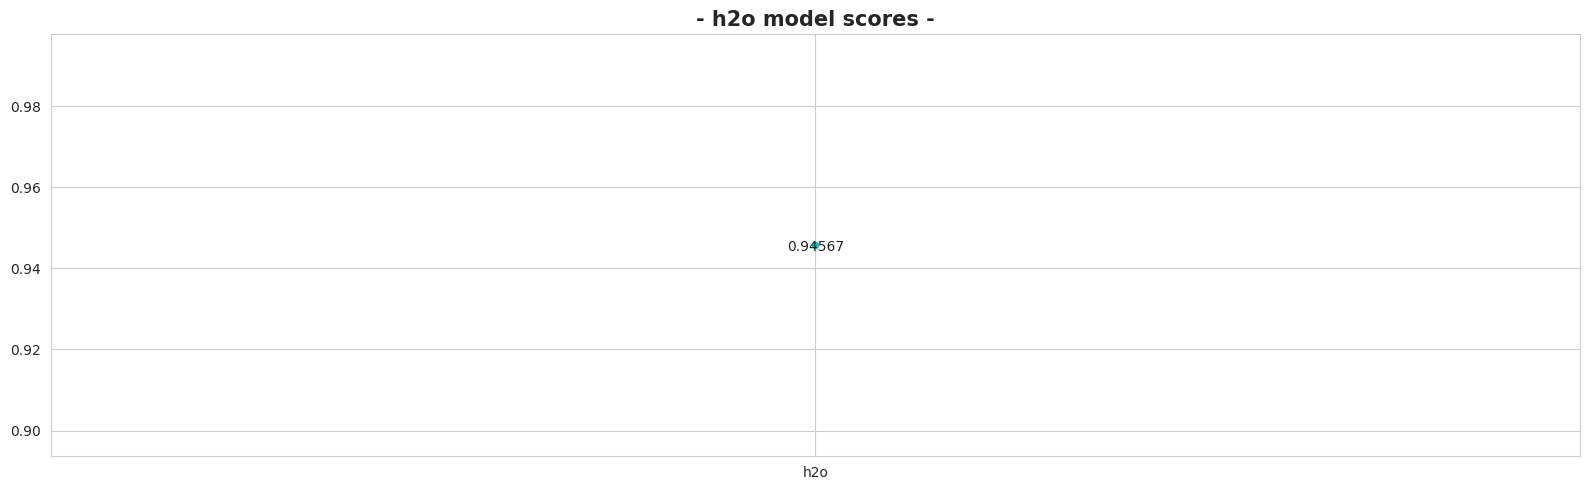

In [39]:
## -- Get Scores -- 
all_model_scores = {}
all_scores = []

for k, v in all_predictions.items():
    for x, y in v.items():
        if x == "score":
            all_model_scores[k] = y
            all_scores.append(float(y))

print(all_model_scores)

plt.figure(figsize=(16, 5))
sns.lineplot(all_model_scores, marker="o")
plt.title("- h2o model scores -", fontsize=15, fontweight="semibold")
plt.tick_params("x", rotation=0)

for i, s in enumerate(all_model_scores.values()):
    plt.text(float(i), s+1e-5, s, ha="center", va="center_baseline")

plt.tight_layout()
plt.show()

In [40]:
## -- Best of each algorithm group: OOF / TEST predictions:  --
for i, (k, v) in enumerate(all_predictions.items()):
    for x, y in v.items():
        if x == "h2o":
            for (mod, oof_, test_) in y:
                ## -- Save oof predictions --
                n = f"{k}_{mod}"
                np.save(f"oof_{n}_.npy", oof_)
                np.save(f"test_{n}_.npy", test_)
                print(f"Model: {CFG['YELLOW']}{n} {CFG['RESET']}oof/test files saved!")
                # ----------------------------------------------------------------------
                preds_ = np.argmax(test_, axis=1)
                counts = [np.sum(preds_ == _) for _ in range(len(np.unique(preds_)))]

                fig, axs = plt.subplots(1, 2, figsize=(16, 5))
                axs[0].bar([*mapping.keys()], counts, color="#73D2DE", edgecolor="k")
                axs[0].set_title(f"{n}: Predicted_labels", color="teal")
                axs[0].set_ylabel("Count")
            
                for i, c in enumerate(counts):
                    axs[0].text(i, c+2500, str(c), ha="center", fontsize=10)
            
                sns.histplot(test_.ravel(), ax=axs[1], color="#FB5607")
                axs[1].set_title(f"{n}: Distribution", color="crimson")
            
                plt.suptitle("Label predictions", fontsize=15, fontweight="semibold")
                plt.tight_layout()
                plt.show()

                print()

oof files saved: h2o_best_94567
test files saved: h2o_best_94567



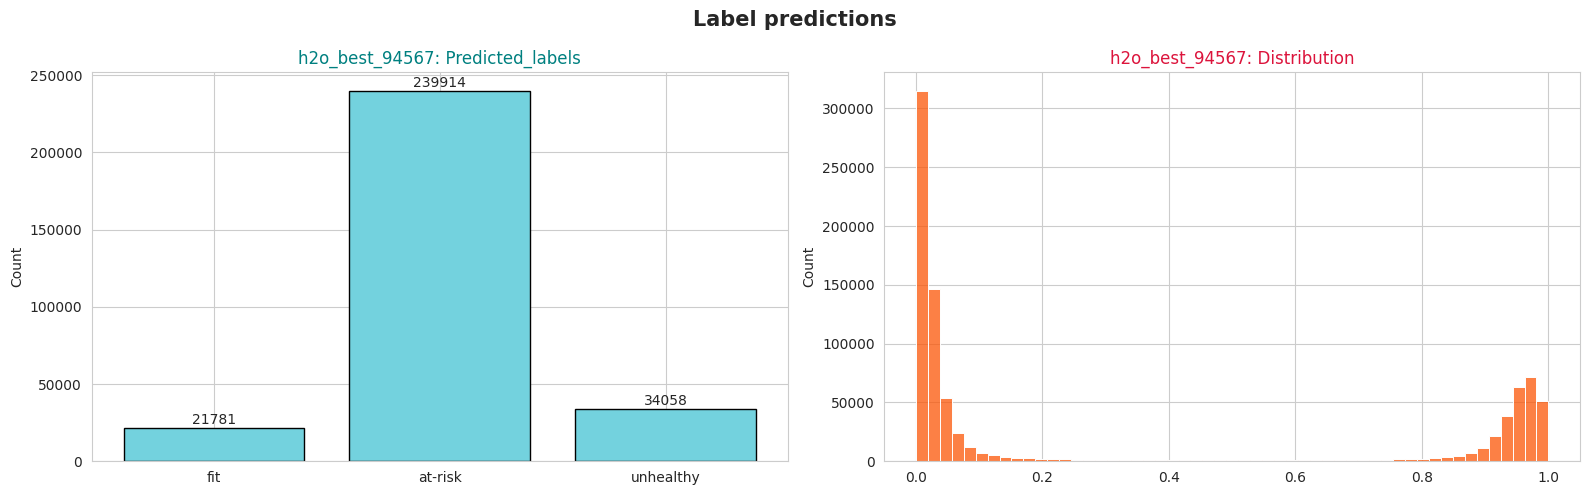

In [41]:
## -- Save BEST MODEL predictions --
for i, (k, v) in enumerate(all_predictions.items()):
    for x, y in v.items():
        ## -- Save TEST predictions --
        if x == "oof_preds":
            n = f"{k}_best_{str(all_scores[i]).split('.')[1]}"
            np.save(f"oof_{n}_.npy", y)
            print(f"oof files saved: {CFG['YELLOW']}{n}{CFG['RESET']}")
        # ----------------------------------------------------------------------
        ## -- Save TEST predictions --
        elif x == "test_preds":
            np.save(f"test_{n}_.npy", y)

            preds_ = np.argmax(y, axis=1)
            submit[TARGET] = pd.Series(preds_).map(r_mapping)
            submit.to_csv(f"submit_{n}.csv", index=False)
            print(f"test files saved: {CFG['YELLOW']}{n}{CFG['RESET']}")
            print()

            counts = [np.sum(preds_ == _) for _ in range(len(np.unique(preds_)))]
        
            fig, axs = plt.subplots(1, 2, figsize=(16, 5))
            axs[0].bar([*mapping.keys()], counts, color="#73D2DE", edgecolor="k")
            axs[0].set_title(f"{n}: Predicted_labels", color="teal")
            axs[0].set_ylabel("Count")
        
            for i, c in enumerate(counts):
                axs[0].text(i, c+2500, str(c), ha="center", fontsize=10)

            sns.histplot(y.ravel(), ax=axs[1], color="#FB5607")
            axs[1].set_title(f"{n}: Distribution", color="crimson")
        
            plt.suptitle("Label predictions", fontsize=15, fontweight="semibold")
            plt.tight_layout()
            plt.show()

            print()

# XAI

# Leaderboard

> Leaderboard shows models with their metrics. When provided with H2OAutoML object, the leaderboard shows 5-fold cross-validated metrics by default (depending on the H2OAutoML settings), otherwise it shows metrics computed on the frame. At most 20 models are shown by default.

model_id,mean_per_class_error,logloss,rmse,mse,training_time_ms,predict_time_per_row_ms,algo
XGBoost_1_AutoML_5_20260723_64846,0.11874,0.0966019,0.159366,0.0253974,527957,0.023471,XGBoost
XGBoost_grid_1_AutoML_5_20260723_64846_model_3,0.119226,0.0950059,0.156866,0.024607,463166,0.020732,XGBoost
XGBoost_grid_1_AutoML_5_20260723_64846_model_6,0.119859,0.0914925,0.155489,0.0241769,980766,0.020748,XGBoost
XGBoost_grid_1_AutoML_5_20260723_64846_model_9,0.120351,0.0944055,0.157333,0.0247535,773815,0.022278,XGBoost
XGBoost_grid_1_AutoML_5_20260723_64846_model_7,0.120399,0.0942111,0.156373,0.0244525,423529,0.021851,XGBoost
XGBoost_grid_1_AutoML_5_20260723_64846_model_2,0.120532,0.0927567,0.155439,0.0241613,763416,0.020588,XGBoost
XGBoost_2_AutoML_5_20260723_64846,0.12062,0.0943194,0.157427,0.0247833,379454,0.017036,XGBoost
XGBoost_grid_1_AutoML_5_20260723_64846_model_5,0.121407,0.0923335,0.155101,0.0240563,329200,0.016042,XGBoost
XGBoost_grid_1_AutoML_5_20260723_64846_model_8,0.121451,0.0910601,0.154777,0.023956,327372,0.012844,XGBoost
GBM_1_AutoML_5_20260723_64846,0.121471,0.0929409,0.155574,0.0242032,202332,0.10454,GBM


# Confusion Matrix

> Confusion matrix shows a predicted class vs an actual class.

## XGBoost_1_AutoML_5_20260723_64846

0,1,2,Error,Rate
6665.0,1273.0,22.0,0.1626884,"1,295 / 7,960"
627.0,117095.0,791.0,0.0119649,"1,418 / 118,513"
16.0,2080.0,9448.0,0.1815662,"2,096 / 11,544"
7308.0,120448.0,10261.0,0.0348435,"4,809 / 138,017"


# Learning Curve Plot

> Learning curve plot shows the loss function/metric dependent on number of iterations or trees for tree-based algorithms. This plot can be useful for determining whether the model overfits.

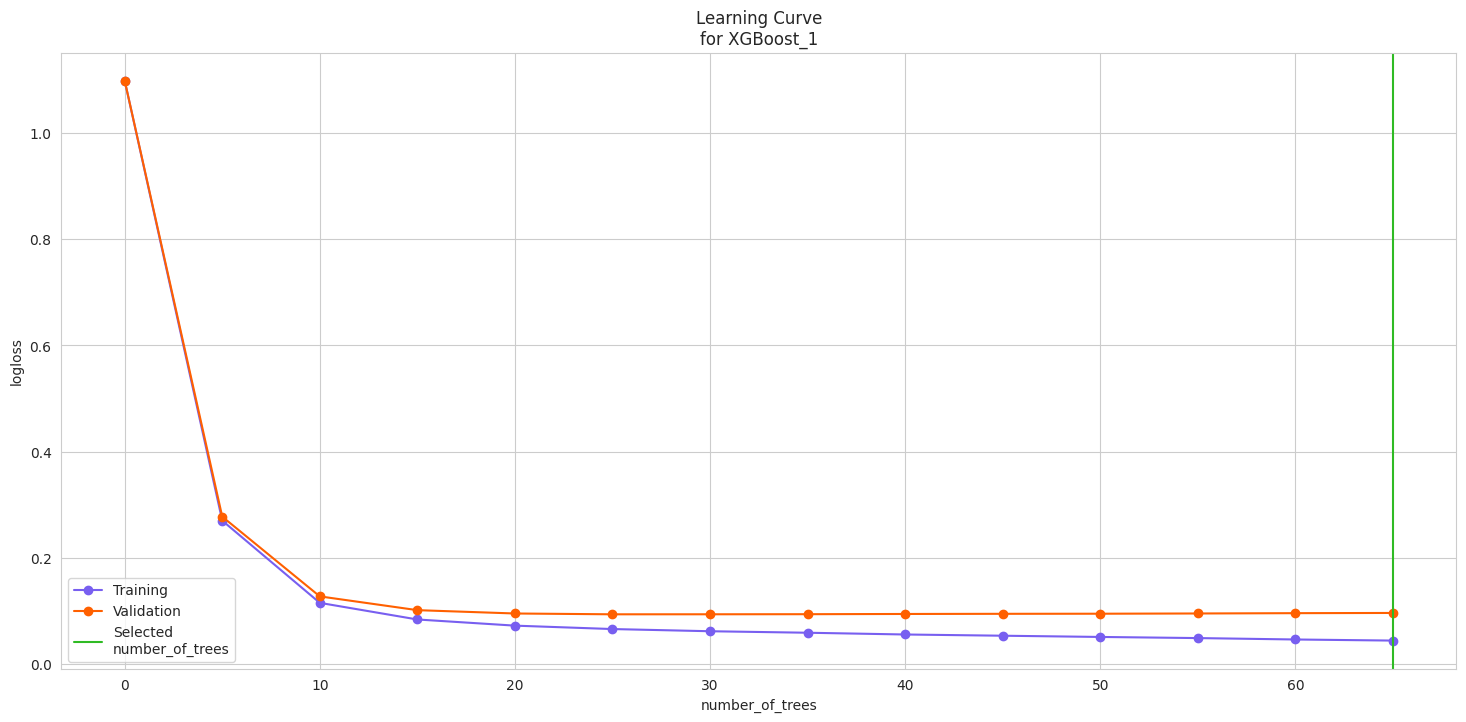

# Variable Importance

> The variable importance plot shows the relative importance of the most important variables in the model.

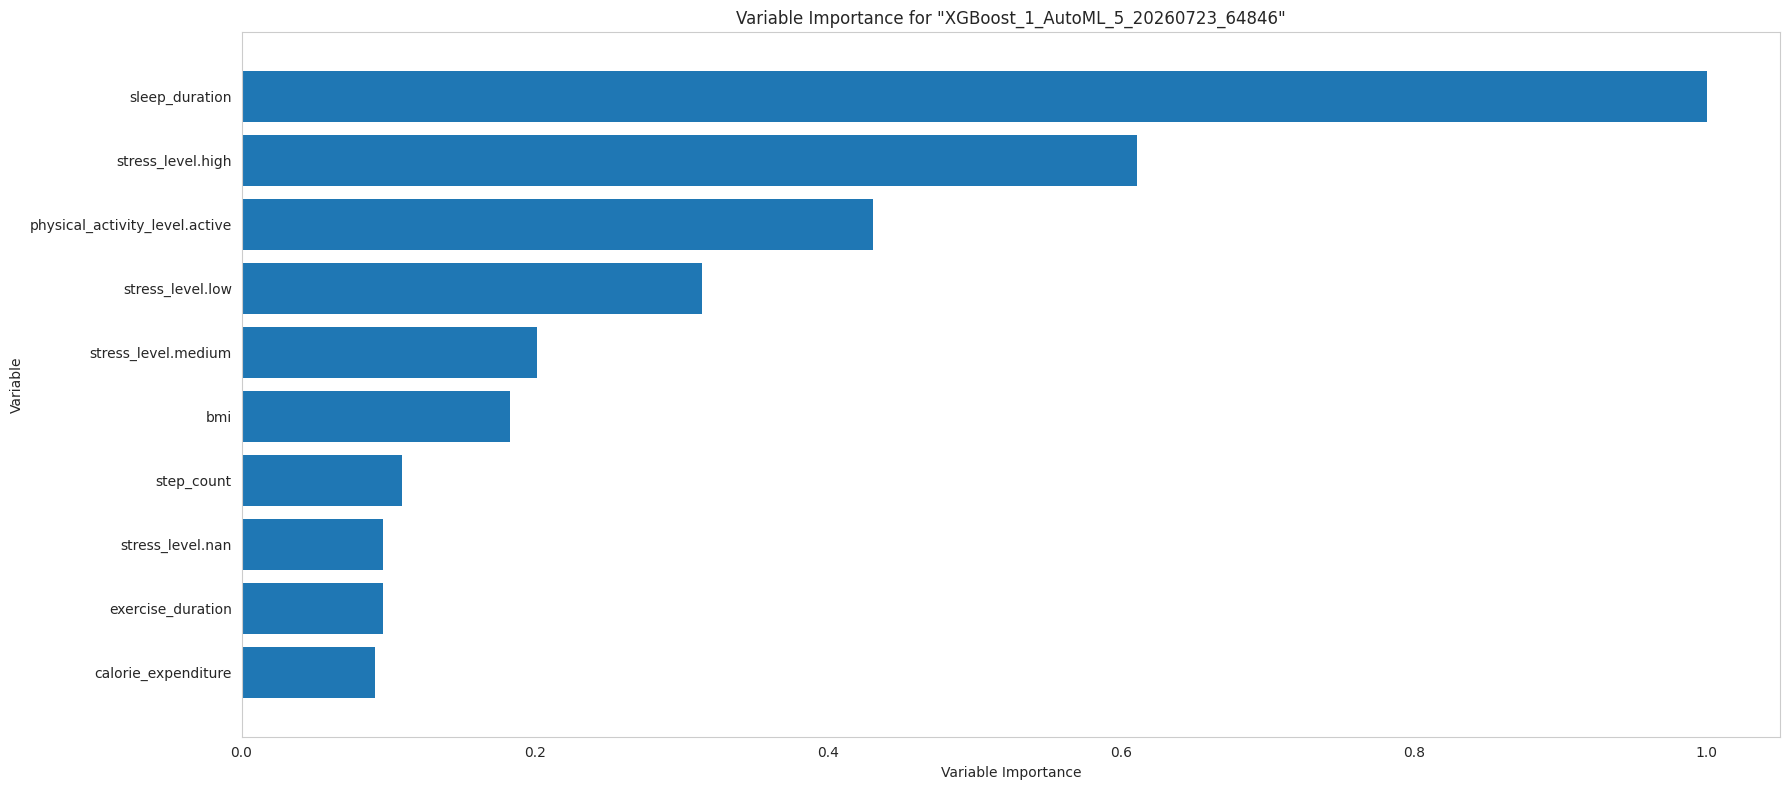

# Variable Importance Heatmap

> Variable importance heatmap shows variable importance across multiple models. Some models in H2O return variable importance for one-hot (binary indicator) encoded versions of categorical columns (e.g. Deep Learning, XGBoost). In order for the variable importance of categorical columns to be compared across all model types we compute a summarization of the the variable importance across all one-hot encoded features and return a single variable importance for the original categorical feature. By default, the models and variables are ordered by their similarity.

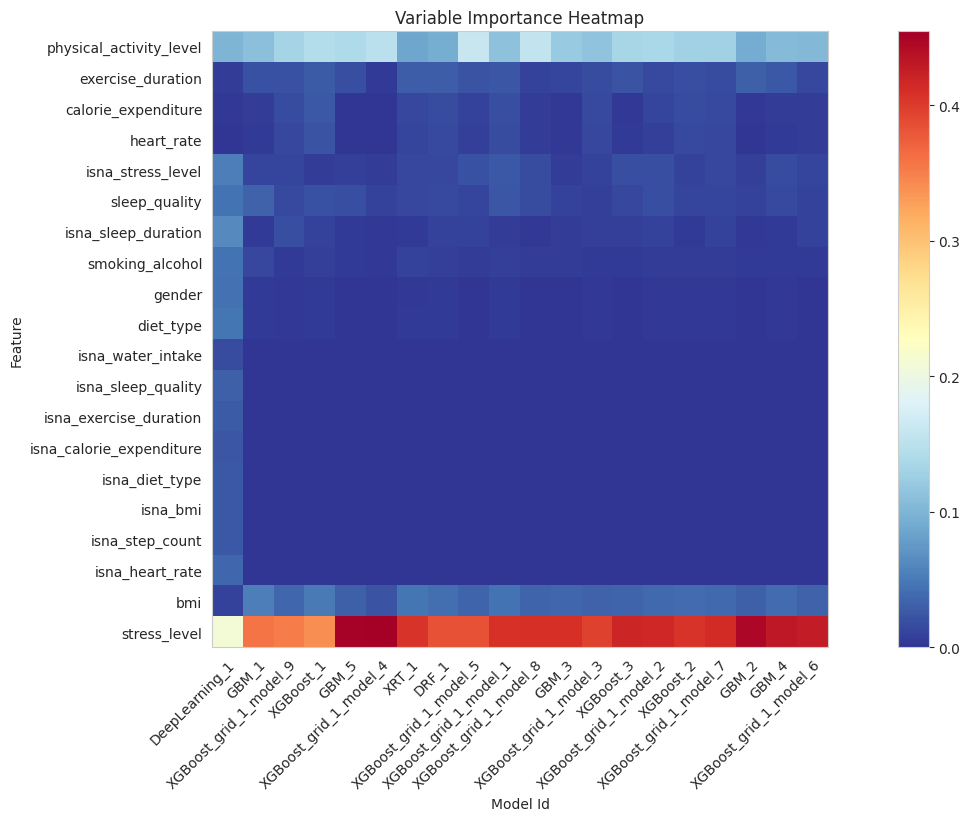

# Model Correlation

> This plot shows the correlation between the predictions of the models. For classification, frequency of identical predictions is used. By default, models are ordered by their similarity (as computed by hierarchical clustering). Interpretable models, such as GAM, GLM, and RuleFit are highlighted using red colored text.

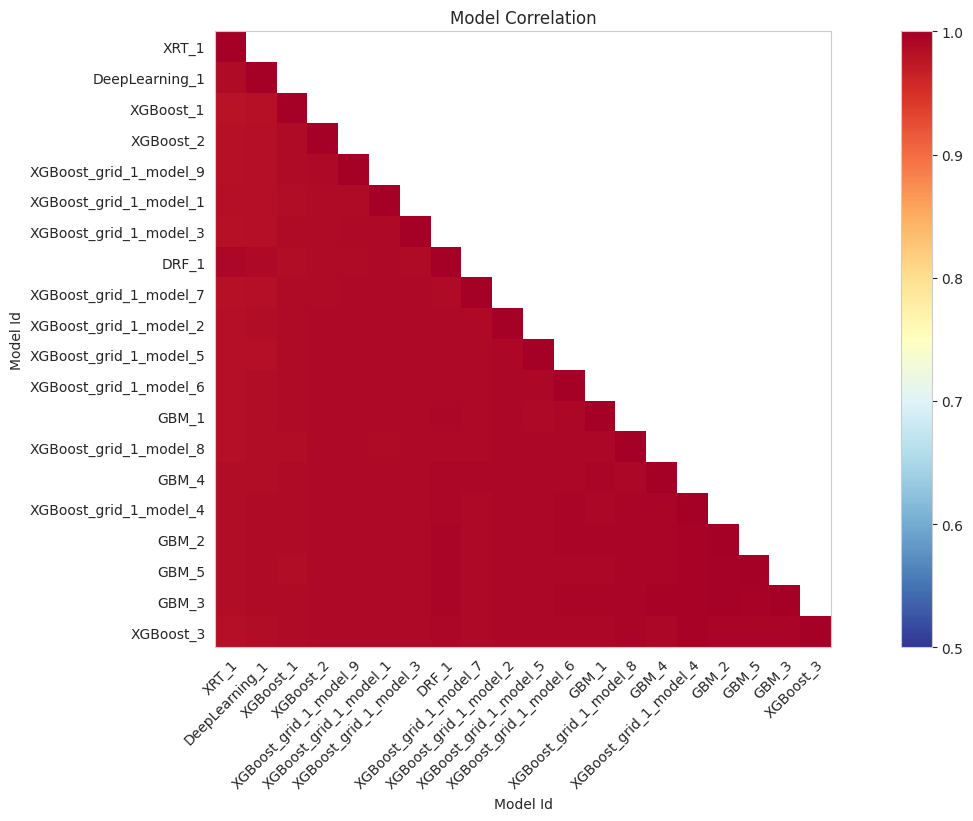

# Leaderboard

> Leaderboard shows models with their metrics. When provided with H2OAutoML object, the leaderboard shows 5-fold cross-validated metrics by default (depending on the H2OAutoML settings), otherwise it shows metrics computed on the frame. At most 20 models are shown by default.

model_id,mean_per_class_error,logloss,rmse,mse,training_time_ms,predict_time_per_row_ms,algo
XGBoost_1_AutoML_5_20260723_64846,0.11874,0.0966019,0.159366,0.0253974,527957,0.023471,XGBoost
XGBoost_grid_1_AutoML_5_20260723_64846_model_3,0.119226,0.0950059,0.156866,0.024607,463166,0.020732,XGBoost
XGBoost_grid_1_AutoML_5_20260723_64846_model_6,0.119859,0.0914925,0.155489,0.0241769,980766,0.020748,XGBoost
XGBoost_grid_1_AutoML_5_20260723_64846_model_9,0.120351,0.0944055,0.157333,0.0247535,773815,0.022278,XGBoost
XGBoost_grid_1_AutoML_5_20260723_64846_model_7,0.120399,0.0942111,0.156373,0.0244525,423529,0.021851,XGBoost
XGBoost_grid_1_AutoML_5_20260723_64846_model_2,0.120532,0.0927567,0.155439,0.0241613,763416,0.020588,XGBoost
XGBoost_2_AutoML_5_20260723_64846,0.12062,0.0943194,0.157427,0.0247833,379454,0.017036,XGBoost
XGBoost_grid_1_AutoML_5_20260723_64846_model_5,0.121407,0.0923335,0.155101,0.0240563,329200,0.016042,XGBoost
XGBoost_grid_1_AutoML_5_20260723_64846_model_8,0.121451,0.0910601,0.154777,0.023956,327372,0.012844,XGBoost
GBM_1_AutoML_5_20260723_64846,0.121471,0.0929409,0.155574,0.0242032,202332,0.10454,GBM


# Confusion Matrix

> Confusion matrix shows a predicted class vs an actual class.

## XGBoost_1_AutoML_5_20260723_64846

0,1,2,Error,Rate
6665.0,1273.0,22.0,0.1626884,"1,295 / 7,960"
627.0,117095.0,791.0,0.0119649,"1,418 / 118,513"
16.0,2080.0,9448.0,0.1815662,"2,096 / 11,544"
7308.0,120448.0,10261.0,0.0348435,"4,809 / 138,017"


# Learning Curve Plot

> Learning curve plot shows the loss function/metric dependent on number of iterations or trees for tree-based algorithms. This plot can be useful for determining whether the model overfits.

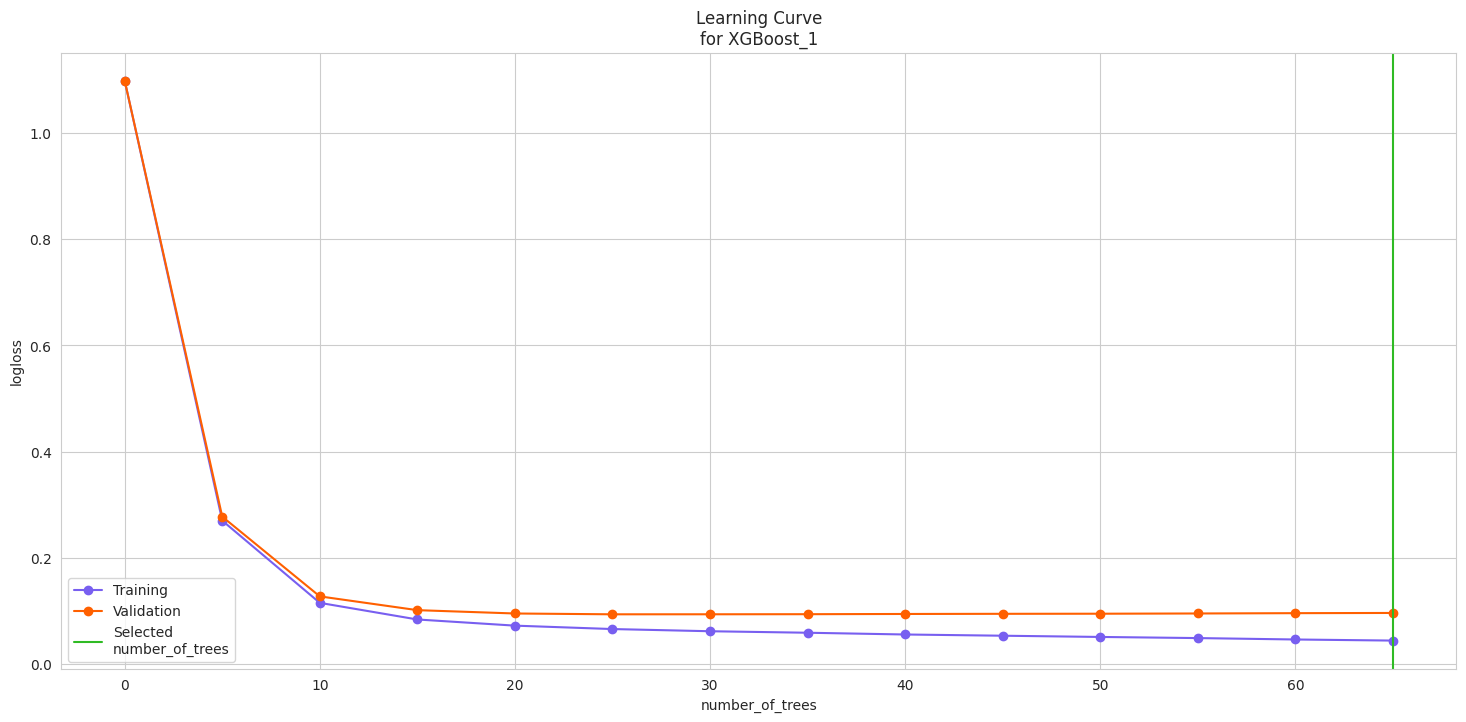

# Variable Importance

> The variable importance plot shows the relative importance of the most important variables in the model.

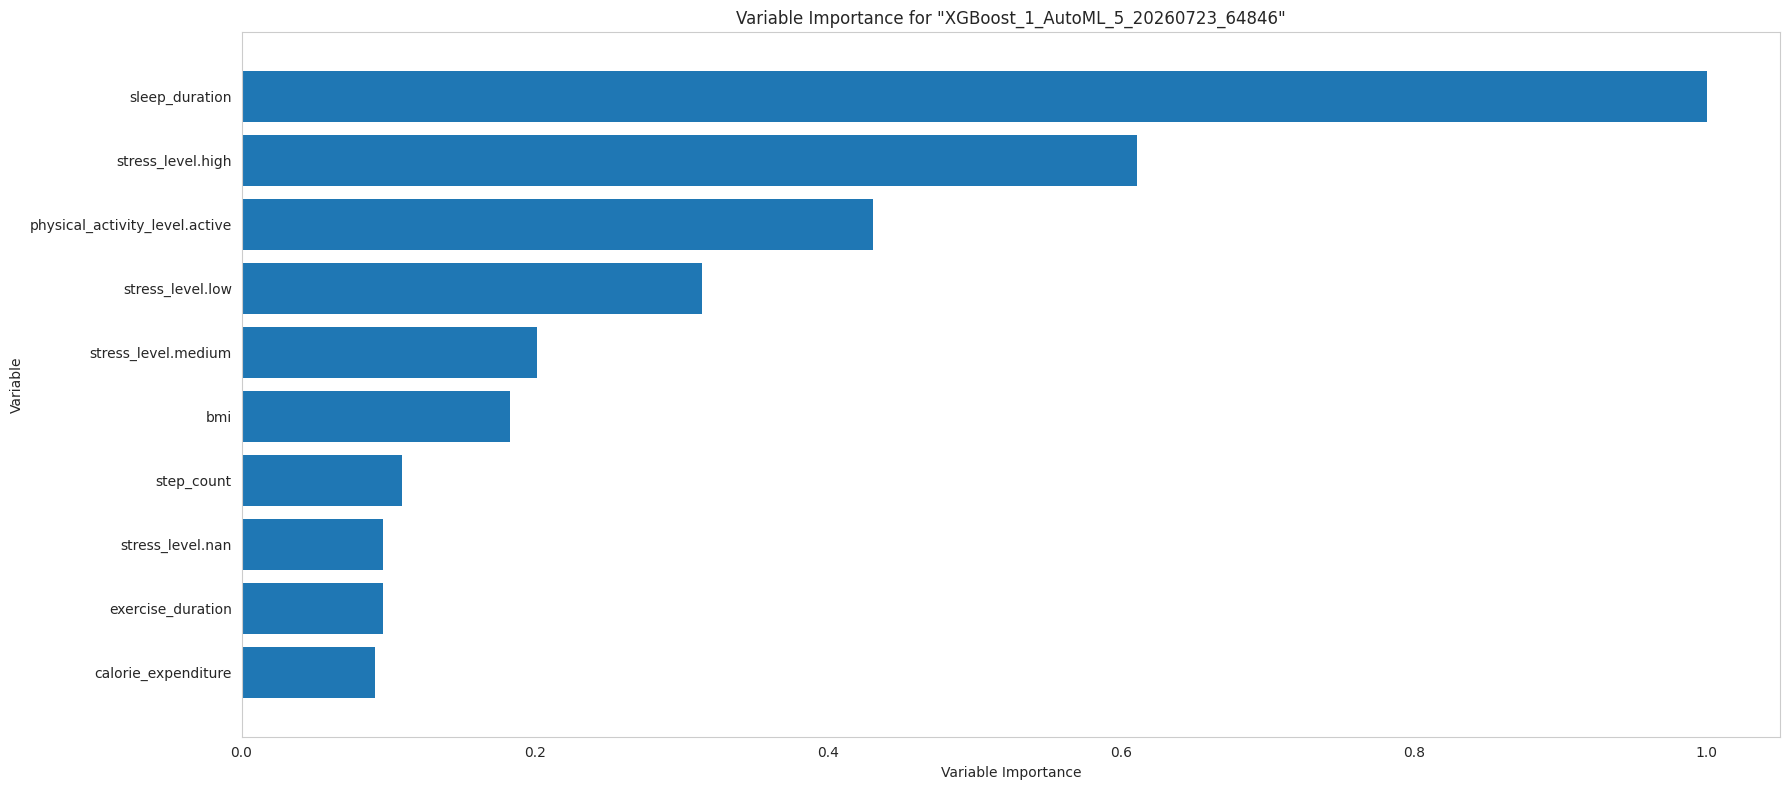

# Variable Importance Heatmap

> Variable importance heatmap shows variable importance across multiple models. Some models in H2O return variable importance for one-hot (binary indicator) encoded versions of categorical columns (e.g. Deep Learning, XGBoost). In order for the variable importance of categorical columns to be compared across all model types we compute a summarization of the the variable importance across all one-hot encoded features and return a single variable importance for the original categorical feature. By default, the models and variables are ordered by their similarity.

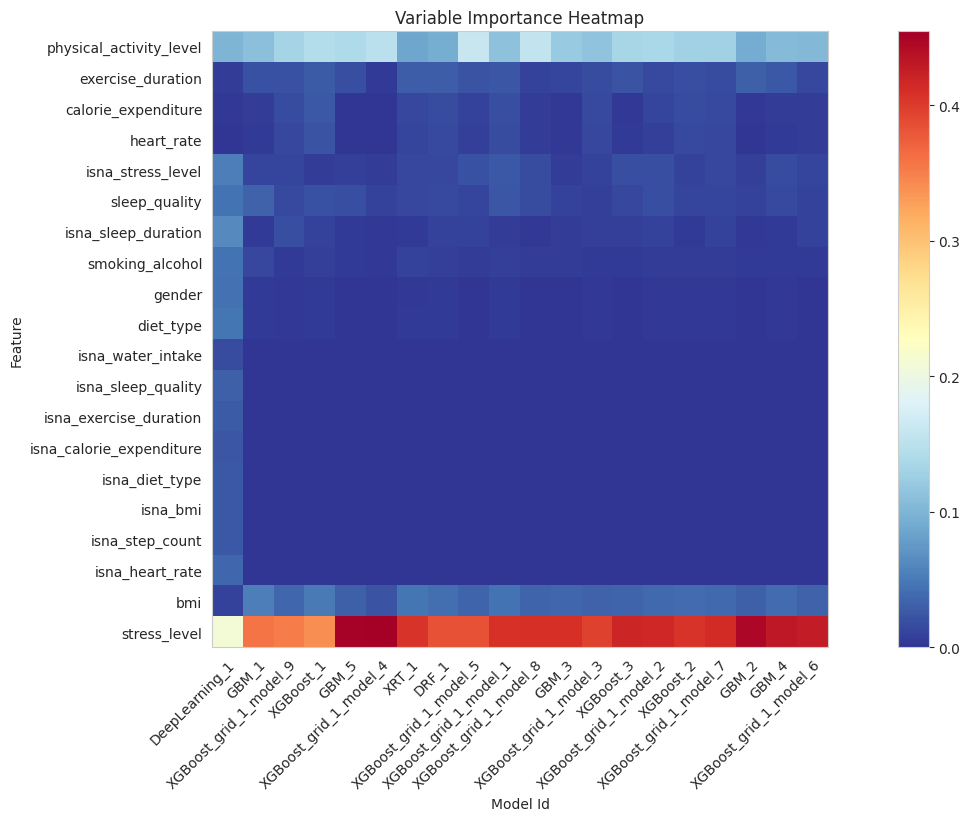

# Model Correlation

> This plot shows the correlation between the predictions of the models. For classification, frequency of identical predictions is used. By default, models are ordered by their similarity (as computed by hierarchical clustering). Interpretable models, such as GAM, GLM, and RuleFit are highlighted using red colored text.

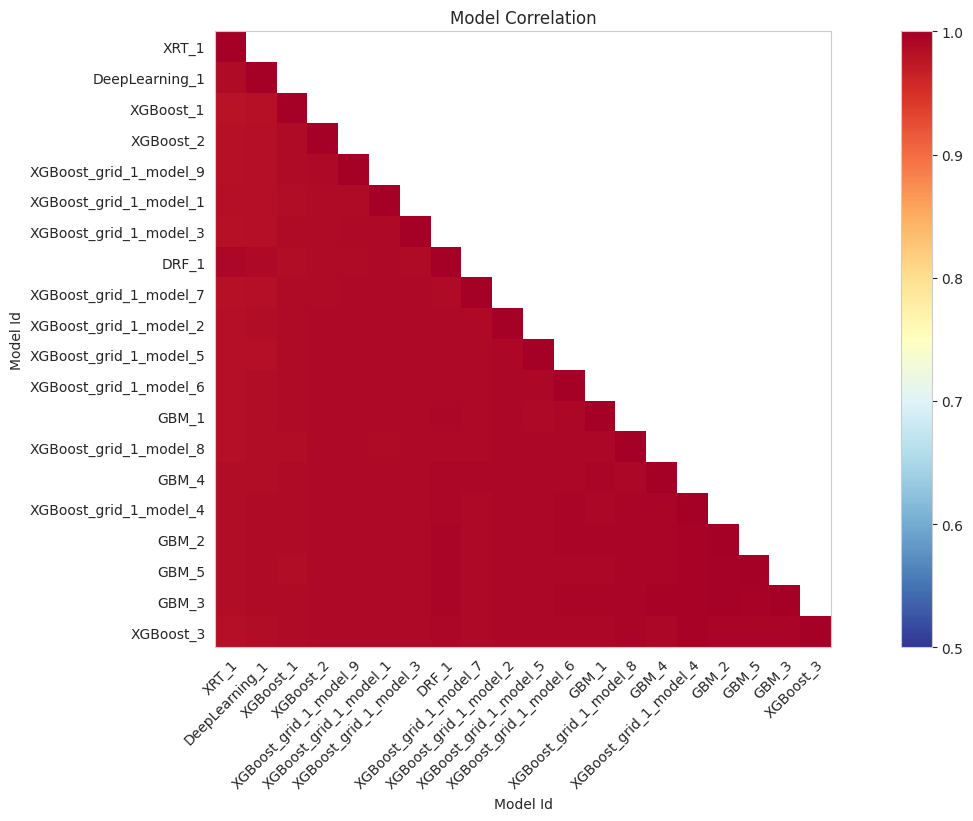

In [42]:
## -- Inspect model -- 
get_model = all_predictions[list(all_predictions.keys())[0]]

get_model["model"].explain(
    get_model["val_data"],
    exclude_explanations=["pdp", "shap_summary"],
    top_n_features=3,
    figsize=(18, 8),
)

# --- OR ----- ##

# h2o.explain(get_model['model'], get_model['val_data'], top_n_features=3,
#             figsize=(18, 8), exclude_explanations=['shap_summary'])

In [43]:
h2o.cluster().shutdown()

# HILLCLIMB

In [44]:
# try:
#     from hillclimbers import climb_hill, partial
# except:
#     %pip install -q -U hillclimbers
#     from hillclimbers import climb_hill, partial

In [45]:
def dataloader(filepath, train_prefix, test_prefix):    
    # Store dataframes in lists
    train_list = []
    test_list  = []

    print('Loading .npy files: ')
    for (root, dirs, files) in os.walk(filepath):
        # Filter files first to ensure accurate tqdm count
        npy_files = [f for f in sorted(files) if f.endswith('.npy')]
        
        for file in tqdm(npy_files):
            arr = np.load(os.path.join(root, file))
            base_name = file.replace('.npy', '')
            
            # Create the 3-column chunk
            new_cols = pd.DataFrame(
                arr, 
                columns=[f"{base_name}_c{c}" for c in range(3)]
            )
            
            if train_prefix in file:
                train_list.append(new_cols)
            elif test_prefix in file:
                test_list.append(new_cols)
    
    # Concatenate everything at once
    train_df = pd.concat(train_list, axis=1) if train_list else pd.DataFrame()
    test_df  = pd.concat(test_list, axis=1) if test_list else pd.DataFrame()

    train_df.columns = [c.replace('oof_', '') for c in train_df.columns]
    test_df.columns  = [c.replace('test_', '') for c in test_df.columns]
    
    return train_df, test_df, train_list

def rename_duplicate_cols(df: pd.DataFrame) -> pd.DataFrame:
    original_cols = list(df.columns)
    new_cols = []
    # Track how many times we've seen each original name
    seen = {}

    for col in tqdm(original_cols, desc="Fixing columns"):
        if col not in seen:
            # First occurrence: keep name unchanged
            seen[col] = 1
            new_cols.append(col)
        else:
            # Duplicate: append suffix _k where k starts at 0
            suffix = seen[col] - 1 # 0 for first duplicate, 1 for second,
            new_name = f"{col}_{suffix}"
            new_cols.append(new_name)
            seen[col] += 1

    # Apply new column names
    df_renamed = df.copy()
    df_renamed.columns = new_cols

    return df_renamed
    
print('Data loader function ready!')

Data loader function ready!


In [46]:
# OOF_PATH = "/kaggle/working/"
# oof_df, test_df, col_names = dataloader(OOF_PATH, "oof", "test")

# per_model_class_output = []
# desc = 'Extracting class names'

# for model in tqdm(col_names, total=len(col_names), desc=desc):
#     model.columns = [c.replace("oof_", "") for c in model.columns]
#     per_model_class_output.append(model.columns.tolist())

# ## -- Drop models if necessary --
# for c in oof_df.columns:
#     if "best" in c: #
#         oof_df.drop(columns=[c],  inplace=True)
#         test_df.drop(columns=[c], inplace=True)

# print("-"*50)
# ## -- Check for missingness --
# print(f"OOF  Null: {oof_df.isna().sum().sum()} | ",end="")
# print(f"TEST Null: {test_df.isna().sum().sum()}")
# print("-"*50)

# ## -- Apply column rename function --
# oof_df  = rename_duplicate_cols(oof_df)
# test_df = rename_duplicate_cols(test_df)

# print()
# print(f"{CFG['YELLOW']} • Columns updated: {oof_df.shape[1]}")

# display(oof_df.head(3))
# print()
# display(test_df.head(3))

In [47]:
# %%time

# trn = pd.read_csv(PATH+"train.csv").drop(columns=['id'])
# pred_hc, oof_hc = climb_hill(
#                                train = train_data,
#                               target = TARGET,
#                          oof_pred_df = oof_df,
#                         test_pred_df = test_df,
#                            objective = "maximize",
#                          eval_metric = partial(roc_auc_score),
#                     # negative_weights = True,
#                     return_oof_preds = True,
#                            precision = 0.01,
#                            plot_hill = True,
#                            plot_hist = True,
# )

In [48]:
# hc_score = str(round(roc_auc_score(train_data[TARGET], oof_hc), 5)).split('.')[1]
# print(f"Hillclimb score: {hc_score}")

# np.save(f"oof_{VERS}_hillclimb_{hc_score}_.npy", oof_hc)
# np.save(f"test_{VERS}_hillclimb_{hc_score}_.npy", pred_hc)

# submit[TARGET] = pred_hc
# submit.to_csv(f"submit_{VERS}_hillclimb_{hc_score}.csv", index=False)
# print(f"\n✅ Saved hillclimb ensemble!")

# submit.head(10)